# Resident Risk Assessment Model

This model identifies which residents at Luz de Vida safehouses are at risk of regression or stagnation, and which are progressing toward successful reintegration. With limited staff managing multiple safehouses, leadership needs a data-driven system to flag girls who may be falling through the cracks before their situation deteriorates.

The pipeline produces a **per-resident risk score** that social workers and program managers can use to:
- Prioritize attention toward residents showing early warning signs
- Allocate resources (counseling, health services, family engagement) where they are most needed
- Surface cases where objective indicators diverge from a social worker's subjective assessment

This notebook covers **Step 1 (Business Problem Framing)** and **Step 2 (Data Acquisition and Preparation)**. Later notebooks will handle exploration, modeling, evaluation, feature selection, and deployment.

## Step 1 -- Business Problem Framing

### 1.1 Business Question

**Which residents are at risk of regression or stagnation, and which are progressing toward successful reintegration?**

Luz de Vida operates safehouses for at-risk girls. Each resident moves through a lifecycle -- intake, case assessment, counseling, education, health services, and ultimately reintegration or placement. Staff are stretched thin across multiple locations, so it is possible for a resident to stagnate or regress without anyone noticing until the situation is serious. This pipeline produces a per-resident risk score so that social workers and program managers can prioritize attention, allocate resources, and intervene early.

### 1.2 Prediction vs. Explanation

This pipeline will produce **two distinct models**:

- **Predictive model**: Optimized for out-of-sample performance. The goal is an accurate risk score per resident. Interpretability is secondary. Ensemble methods (random forest, gradient boosting) are appropriate here because they capture non-linear interactions and generally produce the best discrimination on tabular data.
- **Explanatory model**: A carefully specified logistic regression where coefficient interpretability matters. This model answers the question: *"What factors most drive a girl being at risk?"* Coefficients will be interpretable in business terms (e.g., "each additional self-harm incident is associated with X% higher odds of stagnation"). This gives leadership actionable, defensible insights they can communicate to funders and staff.

### 1.3 Target Variable

The target is derived from `reintegration_status` in the `residents` table:

| reintegration_status | Label | Encoding |
|---------------------|-------|----------|
| On Hold | At-risk | 1 |
| Not Started | At-risk | 1 |
| In Progress | Progressing | 0 |
| Completed | Progressing | 0 |

**Why this variable?** `case_status` was considered but rejected because it conflates program exit reasons (successful reintegration vs. transfer vs. dropout) without encoding progression quality. `current_risk_level` was also considered but rejected because it is a subjective social worker assessment -- the whole point of this model is to surface girls whose *objective* indicators don't match their assigned risk level.

### 1.4 Success Metrics

- **Primary metric**: AUC-ROC -- appropriate for imbalanced binary classification and for producing a ranked risk score rather than just a label
- **Secondary metric**: Recall on the at-risk class -- missing a girl who is actually at risk is far more costly than a false alarm, so the model should minimize false negatives
- **Baseline**: A naive classifier that labels every resident as "progressing" (the majority class). The model must meaningfully outperform this baseline on both metrics.

### 1.5 Dataset Feasibility Note

The dataset contains only **60 residents**. This small sample size shapes every downstream decision:

1. **Cross-validation is mandatory** -- a single train/test split would be too noisy. Stratified k-fold (5-fold or 10-fold) will be used to get stable performance estimates.
2. **Feature selection is critical** -- with 60 rows and potentially dozens of engineered features, overfitting is the primary risk. Aggressive dimensionality reduction (low-variance removal, VIF pruning, importance-based selection) will be applied before final modeling.

## Step 2 -- Data Acquisition and Preparation

Data is drawn from eight tables spanning resident demographics, education, health, incidents, interventions, home visits, counseling sessions, and safehouse metadata. Following the Chapter 7 two-tier pipeline structure, a dataset-specific `wrangle_residents()` function handles project-specific cleaning, while generalizable functions (`missing_fill()`, `skew_correct()`, `encode_categoricals()`, `drop_low_variance()`) can be reused across pipelines.

Tables loaded:
- **residents.csv** -- Core table; source of target variable and static resident features
- **education_records.csv** -- Monthly education snapshots (attendance, progress, enrollment)
- **health_wellbeing_records.csv** -- Monthly health snapshots (physical and psychological scores)
- **incident_reports.csv** -- Irregular incident events (type, severity, resolution)
- **intervention_plans.csv** -- One row per plan per resident (plan status and category)
- **home_visitations.csv** -- Family visit records (cooperation, safety concerns, outcomes)
- **process_recordings.csv** -- Counseling session records (emotional state, concerns, referrals)
- **safehouses.csv** -- Safehouse metadata (capacity) for contextual join only

**Not loaded**: `safehouse_monthly_metrics.csv` (derived from the same data used for features -- leakage risk), `public_impact_snapshots.csv`, `social_media_posts.csv`, `partners.csv`, `partner_assignments.csv`, or any donation-related tables.

In [1]:
# -- Configuration ------------------------------------------------------------
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import yeojohnson

TODAY = pd.Timestamp("2026-04-07")   # reference date for recency calculations
DATA_DIR = Path("dataset")

# Target encoding
AT_RISK_STATUSES = ["On Hold", "Not Started"]

# Columns to drop immediately due to data leakage
LEAKAGE_COLS = [
    "current_risk_level",      # social worker's own risk assessment -- proxy for target
    "date_closed",             # only populated for closed/exited cases -- leakage
    "initial_case_assessment", # early proxy that encodes expected outcome
    "reintegration_type",      # downstream outcome, not an input feature
    "date_enrolled",           # administrative, not predictive
    "notes_restricted",        # free text flag, no predictive value
    "internal_code",           # administrative ID
    "case_control_no",         # administrative ID
]

# Recency features to drop -- days-since-last columns encode case closure
# for completed residents rather than genuine engagement patterns (borderline leakage)
RECENCY_DROP_COLS = [
    "medical_checkup_done_days_since",
    "dental_checkup_done_days_since",
    "psychological_checkup_done_days_since",
    "incident_days_since_last",
    "visit_days_since_last",
    "safety_concerns_days_since",
    "follow_up_needed_days_since",
    "session_days_since_last",
    "progress_noted_days_since",
    "concerns_flagged_days_since",
    "referral_made_days_since",
]

# Ordinal encoding maps
COOPERATION_MAP = {"Uncooperative": 1, "Neutral": 2, "Cooperative": 3, "Highly Cooperative": 4}
VISIT_OUTCOME_MAP = {"Unfavorable": 1, "Inconclusive": 2, "Needs Improvement": 3, "Favorable": 4}
SEVERITY_MAP = {"Low": 1, "Medium": 2, "High": 3}
EMOTIONAL_STATE_MAP = {"Withdrawn": 1, "Distressed": 1, "Angry": 2, "Sad": 2, "Anxious": 3, "Calm": 4, "Hopeful": 5, "Happy": 5}
PLAN_STATUS_MAP = {"Closed": 1, "On Hold": 2, "Open": 3, "In Progress": 4, "Achieved": 5}
RISK_LEVEL_MAP = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}

print(f"Reference date: {TODAY.date()}")
print("Lookback window: full history (all available data per resident)")

Reference date: 2026-04-07
Lookback window: full history (all available data per resident)


In [2]:
# -- Load all tables ----------------------------------------------------------
residents    = pd.read_csv(DATA_DIR / "residents.csv")
education    = pd.read_csv(DATA_DIR / "education_records.csv")
health       = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv")
incidents    = pd.read_csv(DATA_DIR / "incident_reports.csv")
plans        = pd.read_csv(DATA_DIR / "intervention_plans.csv")
visitations  = pd.read_csv(DATA_DIR / "home_visitations.csv")
recordings   = pd.read_csv(DATA_DIR / "process_recordings.csv")
safehouses   = pd.read_csv(DATA_DIR / "safehouses.csv")

# Parse date columns
education["record_date"]    = pd.to_datetime(education["record_date"])
health["record_date"]       = pd.to_datetime(health["record_date"])
incidents["incident_date"]  = pd.to_datetime(incidents["incident_date"])
visitations["visit_date"]   = pd.to_datetime(visitations["visit_date"])
recordings["session_date"]  = pd.to_datetime(recordings["session_date"])

print(f"residents:    {residents.shape}")
print(f"education:    {education.shape}")
print(f"health:       {health.shape}")
print(f"incidents:    {incidents.shape}")
print(f"plans:        {plans.shape}")
print(f"visitations:  {visitations.shape}")
print(f"recordings:   {recordings.shape}")
print(f"safehouses:   {safehouses.shape}")

residents:    (60, 49)
education:    (534, 10)
health:       (534, 14)
incidents:    (100, 12)
plans:        (180, 11)
visitations:  (1337, 14)
recordings:   (2819, 15)
safehouses:   (9, 13)


### 2.3 Target Variable Construction

The binary target `at_risk` is derived from `reintegration_status`: "On Hold" or "Not Started" -> 1 (at-risk), "In Progress" or "Completed" -> 0 (progressing). After constructing the target, `reintegration_status` is dropped so it cannot leak into features.

In [3]:
# -- Drop leakage columns and construct target --------------------------------
residents.drop(columns=[c for c in LEAKAGE_COLS if c in residents.columns], inplace=True)

residents["at_risk"] = residents["reintegration_status"].isin(AT_RISK_STATUSES).astype(int)

print("Class distribution:")
print(residents["at_risk"].value_counts().rename({0: "Progressing (0)", 1: "At-risk (1)"}))
print(f"\nImbalance ratio: {residents['at_risk'].value_counts()[0]} : {residents['at_risk'].value_counts()[1]}")
print("Note: class weighting or SMOTE will be applied at modeling time to handle this imbalance.")

# Drop reintegration_status so it cannot leak into features
residents.drop(columns=["reintegration_status"], inplace=True)

Class distribution:
at_risk
Progressing (0)    40
At-risk (1)        20
Name: count, dtype: int64

Imbalance ratio: 40 : 20
Note: class weighting or SMOTE will be applied at modeling time to handle this imbalance.


### 2.4 Data Scope

All available records are used from each longitudinal table -- no date window filter is applied. With only 60 residents and limited history per resident, restricting to a fixed window would discard too much signal. Using the full history maximizes the data available for slope, mean, and volatility calculations.

For intervention plans, the same applies -- the full plan history is used since each resident has exactly one plan per category.

In [4]:
# -- Use all available records (no date window filter) -------------------------
edu_w    = education.copy()
health_w = health.copy()
inc_w    = incidents.copy()
vis_w    = visitations.copy()
rec_w    = recordings.copy()

print(f"education:    {edu_w.shape[0]} records")
print(f"health:       {health_w.shape[0]} records")
print(f"incidents:    {inc_w.shape[0]} records")
print(f"visitations:  {vis_w.shape[0]} records")
print(f"recordings:   {rec_w.shape[0]} records")
print(f"plans:        {plans.shape[0]} records")

education:    534 records
health:       534 records
incidents:    100 records
visitations:  1337 records
recordings:   2819 records
plans:        180 records


### 2.5 Feature Engineering

Each source table gets its own feature-building function that returns a flat, one-row-per-resident DataFrame. All functions follow the column-type rules defined in the prompt: rates/percents get slope + mean, scores get slope + mean + std, booleans get proportion + recency, ordered categoricals get numeric encoding then mean + slope, unordered categoricals get proportions, and dates yield count + recency. Free text and admin IDs are dropped.

In [5]:
# -- Reusable helper: compute slope -------------------------------------------
def compute_slope(series: pd.Series) -> float:
    """Return OLS slope of series values over index positions. Returns NaN if fewer than 2 points."""
    clean = series.dropna()
    if len(clean) < 2:
        return np.nan
    x = np.arange(len(series))
    mask = ~series.isna()
    return np.polyfit(x[mask], series[mask], 1)[0]


def bool_proportion(series: pd.Series) -> float:
    """Proportion of True values in a boolean series."""
    if len(series) == 0:
        return np.nan
    return series.sum() / len(series)


def days_since_last_true(series: pd.Series, dates: pd.Series, reference: pd.Timestamp) -> float:
    """Days since the most recent True value. NaN if no True values."""
    true_dates = dates[series.astype(bool)]
    if len(true_dates) == 0:
        return np.nan
    return (reference - true_dates.max()).days


print("Helper functions defined.")

Helper functions defined.


In [6]:
# -- Feature engineering: education_records.csv --------------------------------
def build_education_features(df, all_residents):
    """Aggregate education records to one row per resident."""
    df = df.sort_values(["resident_id", "record_date"])

    agg = df.groupby("resident_id").agg(
        attendance_rate_slope=("attendance_rate", compute_slope),
        attendance_rate_mean=("attendance_rate", "mean"),
        progress_percent_slope=("progress_percent", compute_slope),
        progress_percent_mean=("progress_percent", "mean"),
        edu_record_count=("education_record_id", "count"),
    ).reset_index()

    # Completion status proportions
    comp_props = (
        df.groupby("resident_id")["completion_status"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .add_prefix("edu_completion_")
        .reset_index()
    )

    result = all_residents[["resident_id"]].merge(agg, on="resident_id", how="left")
    result = result.merge(comp_props, on="resident_id", how="left")

    print(f"Education features: {result.shape[1] - 1} columns")
    return result

edu_features = build_education_features(edu_w, residents)
edu_features.head()

Education features: 8 columns


,resident_id,attendance_rate_slope,attendance_rate_mean,progress_percent_slope,progress_percent_mean,edu_record_count,edu_completion_Completed,edu_completion_InProgress,edu_completion_NotStarted
0,1,-0.066971,0.716333,3.037143,45.483333,6,0.000000,0.833333,0.166667
1,2,0.014212,0.834300,4.072121,85.230000,10,0.000000,0.900000,0.100000
2,3,0.028036,0.738091,6.059091,71.581818,11,0.090909,0.818182,0.090909
3,4,0.012482,0.757636,1.923636,95.045455,11,0.090909,0.818182,0.090909
4,5,0.023583,0.668111,4.965000,61.388889,9,0.000000,0.888889,0.111111


In [7]:
# -- Feature engineering: health_wellbeing_records.csv -------------------------
def build_health_features(df, all_residents):
    """Aggregate health records to one row per resident."""
    df = df.sort_values(["resident_id", "record_date"])

    score_cols = ["general_health_score", "nutrition_score", "sleep_quality_score", "energy_level_score"]
    physical_cols = ["height_cm", "weight_kg", "bmi"]
    bool_cols = ["medical_checkup_done", "dental_checkup_done", "psychological_checkup_done"]

    rows = []
    for rid, grp in df.groupby("resident_id"):
        row = {"resident_id": rid}

        for col in score_cols:
            row[f"{col}_slope"] = compute_slope(grp[col])
            row[f"{col}_mean"] = grp[col].mean()
            row[f"{col}_std"] = grp[col].std()

        for col in physical_cols:
            row[f"{col}_slope"] = compute_slope(grp[col])
            row[f"{col}_latest"] = grp[col].iloc[-1]

        for col in bool_cols:
            row[f"{col}_prop"] = bool_proportion(grp[col])
            row[f"{col}_days_since"] = days_since_last_true(grp[col], grp["record_date"], TODAY)

        rows.append(row)

    agg = pd.DataFrame(rows)
    result = all_residents[["resident_id"]].merge(agg, on="resident_id", how="left")

    print(f"Health features: {result.shape[1] - 1} columns")
    return result

health_features = build_health_features(health_w, residents)
health_features.head()

Health features: 24 columns


,resident_id,general_health_score_slope,general_health_score_mean,general_health_score_std,nutrition_score_slope,nutrition_score_mean,nutrition_score_std,sleep_quality_score_slope,sleep_quality_score_mean,sleep_quality_score_std,...,weight_kg_slope,weight_kg_latest,bmi_slope,bmi_latest,medical_checkup_done_prop,medical_checkup_done_days_since,dental_checkup_done_prop,dental_checkup_done_days_since,psychological_checkup_done_prop,psychological_checkup_done_days_since
0,1,0.026286,3.103333,0.064395,0.074286,3.210000,0.141280,0.010286,3.203333,0.030111,...,0.280000,36.7,0.037143,15.8,0.500000,796,0.166667,888.0,0.333333,796
1,2,0.043576,3.449000,0.141142,0.074606,3.431000,0.231442,0.024848,3.376000,0.092280,...,0.240000,41.9,0.031515,18.4,0.700000,858,0.600000,888.0,0.500000,919
2,3,0.056455,3.181818,0.200091,0.047545,3.003636,0.185055,0.029909,3.079091,0.137873,...,0.257273,40.3,0.029091,17.2,0.454545,492,0.181818,492.0,0.545455,402
3,4,0.010818,3.157273,0.070724,0.017636,2.983636,0.090915,0.006091,2.881818,0.088184,...,0.312727,41.1,0.070000,17.2,0.454545,280,0.272727,310.0,0.363636,310
4,5,0.006167,3.087778,0.050690,0.010333,3.100000,0.103923,0.013000,2.981111,0.060713,...,0.228333,40.5,0.011667,17.2,0.888889,583,0.000000,NaN,0.333333,614


In [8]:
# -- Feature engineering: incident_reports.csv ---------------------------------
def build_incident_features(df, all_residents):
    """Aggregate incident reports to one row per resident."""
    rows = []
    for rid in all_residents["resident_id"]:
        grp = df[df["resident_id"] == rid]
        row = {"resident_id": rid}

        if len(grp) == 0:
            row["incident_count"] = 0
            row["incident_has_self_harm"] = 0
            row["incident_has_runaway"] = 0
            row["incident_resolution_rate"] = np.nan
            row["incident_days_since_last"] = np.nan
            row["severity_mean"] = np.nan
            row["severity_slope"] = np.nan
        else:
            grp = grp.sort_values("incident_date")
            row["incident_count"] = len(grp)
            row["incident_has_self_harm"] = int((grp["incident_type"] == "SelfHarm").any())
            row["incident_has_runaway"] = int((grp["incident_type"] == "RunawayAttempt").any())
            row["incident_resolution_rate"] = grp["resolved"].sum() / len(grp)
            row["incident_days_since_last"] = (TODAY - grp["incident_date"].max()).days

            sev_encoded = grp["severity"].map(SEVERITY_MAP)
            row["severity_mean"] = sev_encoded.mean()
            row["severity_slope"] = compute_slope(sev_encoded.reset_index(drop=True))

        rows.append(row)

    agg = pd.DataFrame(rows)

    type_props = (
        df.groupby("resident_id")["incident_type"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .add_prefix("incident_type_")
        .reset_index()
    )

    result = agg.merge(type_props, on="resident_id", how="left")
    type_cols = [c for c in result.columns if c.startswith("incident_type_")]
    result[type_cols] = result[type_cols].fillna(0)

    print(f"Incident features: {result.shape[1] - 1} columns")
    return result

incident_features = build_incident_features(inc_w, residents)
incident_features.head()

Incident features: 14 columns


,resident_id,incident_count,incident_has_self_harm,incident_has_runaway,incident_resolution_rate,incident_days_since_last,severity_mean,severity_slope,incident_type_Behavioral,incident_type_ConflictWithPeer,incident_type_Medical,incident_type_PropertyDamage,incident_type_RunawayAttempt,incident_type_Security,incident_type_SelfHarm
0,1,4,0,1,0.75,56.0,1.750000,0.5,0.25,0.000000,0.25,0.0,0.25,0.250000,0.0
1,2,0,0,0,NaN,NaN,NaN,NaN,0.00,0.000000,0.00,0.0,0.00,0.000000,0.0
2,3,2,1,0,0.00,330.0,2.000000,2.0,0.00,0.000000,0.00,0.0,0.00,0.500000,0.5
3,4,3,0,0,1.00,112.0,1.666667,1.0,0.00,0.333333,0.00,0.0,0.00,0.666667,0.0
4,5,2,0,0,0.50,644.0,2.500000,-1.0,0.50,0.000000,0.00,0.0,0.00,0.500000,0.0


In [9]:
# -- Feature engineering: intervention_plans.csv -------------------------------
def build_plan_features(df, all_residents):
    """Pivot intervention plans to one row per resident."""
    df = df.copy()
    df["status_encoded"] = df["status"].map(PLAN_STATUS_MAP)

    pivot = df.pivot_table(
        index="resident_id",
        columns="plan_category",
        values="status_encoded",
        aggfunc="first"
    ).reset_index()

    pivot.columns = ["resident_id"] + [f"plan_{c.lower().replace(' ', '_')}_status" for c in pivot.columns[1:]]

    result = all_residents[["resident_id"]].merge(pivot, on="resident_id", how="left")

    print(f"Plan features: {result.shape[1] - 1} columns")
    return result

plan_features = build_plan_features(plans, residents)
plan_features.head()

Plan features: 3 columns


,resident_id,plan_education_status,plan_physical_health_status,plan_safety_status
0,1,4,2,2
1,2,3,5,2
2,3,2,3,3
3,4,4,4,3
4,5,4,5,4


In [10]:
# -- Feature engineering: home_visitations.csv ---------------------------------
def build_visitation_features(df, all_residents):
    """Aggregate home visitation records to one row per resident."""
    df = df.sort_values(["resident_id", "visit_date"])

    rows = []
    for rid in all_residents["resident_id"]:
        grp = df[df["resident_id"] == rid]
        row = {"resident_id": rid}

        if len(grp) == 0:
            row["visit_count"] = 0
            row["visit_days_since_last"] = np.nan
            row["cooperation_mean"] = np.nan
            row["cooperation_slope"] = np.nan
            row["visit_outcome_mean"] = np.nan
            row["visit_outcome_slope"] = np.nan
            row["safety_concerns_prop"] = np.nan
            row["safety_concerns_days_since"] = np.nan
            row["follow_up_needed_prop"] = np.nan
            row["follow_up_needed_days_since"] = np.nan
        else:
            row["visit_count"] = len(grp)
            row["visit_days_since_last"] = (TODAY - grp["visit_date"].max()).days

            coop = grp["family_cooperation_level"].map(COOPERATION_MAP)
            row["cooperation_mean"] = coop.mean()
            row["cooperation_slope"] = compute_slope(coop.reset_index(drop=True))

            outcome = grp["visit_outcome"].map(VISIT_OUTCOME_MAP)
            row["visit_outcome_mean"] = outcome.mean()
            row["visit_outcome_slope"] = compute_slope(outcome.reset_index(drop=True))

            row["safety_concerns_prop"] = bool_proportion(grp["safety_concerns_noted"])
            row["safety_concerns_days_since"] = days_since_last_true(
                grp["safety_concerns_noted"], grp["visit_date"], TODAY
            )

            row["follow_up_needed_prop"] = bool_proportion(grp["follow_up_needed"])
            row["follow_up_needed_days_since"] = days_since_last_true(
                grp["follow_up_needed"], grp["visit_date"], TODAY
            )

        rows.append(row)

    result = pd.DataFrame(rows)
    print(f"Visitation features: {result.shape[1] - 1} columns")
    return result

visitation_features = build_visitation_features(vis_w, residents)
visitation_features.head()

Visitation features: 10 columns


,resident_id,visit_count,visit_days_since_last,cooperation_mean,cooperation_slope,visit_outcome_mean,visit_outcome_slope,safety_concerns_prop,safety_concerns_days_since,follow_up_needed_prop,follow_up_needed_days_since
0,1,54,43.0,2.925926,3.422908e-02,2.833333,-0.011168,0.166667,60.0,0.500000,43.0
1,2,35,459.0,3.142857,1.904762e-02,3.114286,0.008403,0.314286,460.0,0.485714,469.0
2,3,26,118.0,2.423077,7.897436e-02,2.769231,0.060855,0.423077,354.0,0.461538,118.0
3,4,9,53.0,3.444444,1.673228e-16,3.444444,-0.033333,0.333333,53.0,0.333333,53.0
4,5,11,559.0,3.000000,2.272727e-01,3.181818,0.227273,0.181818,698.0,0.272727,757.0


In [11]:
# -- Feature engineering: process_recordings.csv -------------------------------
def build_recording_features(df, all_residents):
    """Aggregate counseling session records to one row per resident."""
    df = df.sort_values(["resident_id", "session_date"])

    rows = []
    for rid in all_residents["resident_id"]:
        grp = df[df["resident_id"] == rid]
        row = {"resident_id": rid}

        if len(grp) == 0:
            row["session_count"] = 0
            row["session_days_since_last"] = np.nan
            row["emotional_state_end_mean"] = np.nan
            row["emotional_state_end_slope"] = np.nan
            row["session_duration_mean"] = np.nan
            row["sw_distinct_count"] = 0
            row["progress_noted_prop"] = np.nan
            row["progress_noted_days_since"] = np.nan
            row["concerns_flagged_prop"] = np.nan
            row["concerns_flagged_days_since"] = np.nan
            row["referral_made_prop"] = np.nan
            row["referral_made_days_since"] = np.nan
            row["session_type_Individual"] = 0.0
            row["session_type_Group"] = 0.0
        else:
            row["session_count"] = len(grp)
            row["session_days_since_last"] = (TODAY - grp["session_date"].max()).days

            emo = grp["emotional_state_end"].map(EMOTIONAL_STATE_MAP)
            row["emotional_state_end_mean"] = emo.mean()
            row["emotional_state_end_slope"] = compute_slope(emo.reset_index(drop=True))

            row["session_duration_mean"] = grp["session_duration_minutes"].mean()
            row["sw_distinct_count"] = grp["social_worker"].nunique()

            for col in ["progress_noted", "concerns_flagged", "referral_made"]:
                row[f"{col}_prop"] = bool_proportion(grp[col])
                row[f"{col}_days_since"] = days_since_last_true(grp[col], grp["session_date"], TODAY)

            type_counts = grp["session_type"].value_counts(normalize=True)
            for st in ["Individual", "Group"]:
                row[f"session_type_{st}"] = type_counts.get(st, 0.0)

        rows.append(row)

    result = pd.DataFrame(rows)
    print(f"Recording features: {result.shape[1] - 1} columns")
    return result

recording_features = build_recording_features(rec_w, residents)
recording_features.head()

Recording features: 14 columns


,resident_id,session_count,session_days_since_last,emotional_state_end_mean,emotional_state_end_slope,session_duration_mean,sw_distinct_count,progress_noted_prop,progress_noted_days_since,concerns_flagged_prop,concerns_flagged_days_since,referral_made_prop,referral_made_days_since,session_type_Individual,session_type_Group
0,1,106,62,4.330189,0.003381,69.433962,20,0.924528,62,0.235849,62,0.160377,62.0,0.669811,0.330189
1,2,51,475,4.274510,0.003439,68.176471,19,0.921569,475,0.254902,489,0.137255,533.0,0.568627,0.431373
2,3,53,50,4.528302,-0.006370,69.452830,20,0.943396,50,0.188679,140,0.188679,56.0,0.566038,0.433962
3,4,57,44,4.421053,0.002852,69.596491,19,0.964912,44,0.210526,51,0.122807,68.0,0.543860,0.456140
4,5,18,573,4.666667,-0.049536,65.611111,12,1.000000,573,0.166667,579,0.055556,637.0,0.888889,0.111111


### 2.7 Dataset-Specific Wrangling Function

`wrangle_residents()` handles all project-specific cleaning on the residents table before the generalizable pipeline runs. This includes extracting numeric values from string columns (e.g., "15 Years 9 months" -> total months), consolidating rare religion categories, encoding ordinal columns, one-hot encoding nominals, and dropping columns with no predictive value. Region/safehouse location columns are excluded since they are specific to the source dataset and not generalizable.

In [12]:
# -- Dataset-specific wrangling: residents table -------------------------------
import re

def parse_years_months_to_months(s):
    """Parse strings like '15 Years 9 months' to total months as float."""
    if pd.isna(s):
        return np.nan
    m = re.match(r"(\d+)\s*[Yy]ears?\s*(\d+)\s*[Mm]onths?", str(s))
    if m:
        return int(m.group(1)) * 12 + int(m.group(2))
    m = re.match(r"(\d+)\s*[Yy]ears?", str(s))
    if m:
        return int(m.group(1)) * 12
    return np.nan


def wrangle_residents(df, safehouses_df):
    """Project-specific cleaning for the residents table."""
    df = df.copy()

    # Extract numeric age (in months) and length of stay (in months)
    df["age_upon_admission_months"] = df["age_upon_admission"].apply(parse_years_months_to_months)
    df["length_of_stay_months"] = df["length_of_stay"].apply(parse_years_months_to_months)

    # Encode initial_risk_level as ordinal
    df["initial_risk_level_encoded"] = df["initial_risk_level"].map(RISK_LEVEL_MAP)

    # Consolidate rare religion categories (fewer than 3 residents -> "Other")
    religion_counts = df["religion"].value_counts()
    rare_religions = religion_counts[religion_counts < 3].index.tolist()
    df["religion"] = df["religion"].replace(rare_religions, "Other")

    # One-hot encode referral_source and religion (region excluded -- not generalizable)
    df = pd.get_dummies(df, columns=["referral_source", "religion"], drop_first=True)

    # Convert boolean columns to int
    bool_cols = [c for c in df.columns if df[c].dtype == bool]
    for c in bool_cols:
        df[c] = df[c].astype(int)

    # Drop columns with no predictive value (includes safehouse/region columns)
    drop_cols = [
        "sex", "place_of_birth", "date_of_birth", "birth_status",
        "assigned_social_worker", "date_case_study_prepared",
        "date_colb_registered", "date_colb_obtained", "created_at",
        "age_upon_admission", "present_age", "length_of_stay",
        "initial_risk_level", "referring_agency_person", "date_of_admission",
        "case_status", "case_category", "safehouse_id",
        "pwd_type", "special_needs_diagnosis",
    ]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    print(f"Wrangled residents: {df.shape[1]} columns")
    print(f"Columns: {list(df.columns)}")
    return df

residents_clean = wrangle_residents(residents, safehouses)
residents_clean.head()

Wrangled residents: 34 columns
Columns: ['resident_id', 'sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'at_risk', 'age_upon_admission_months', 'length_of_stay_months', 'initial_risk_level_encoded', 'referral_source_Court Order', 'referral_source_Government Agency', 'referral_source_NGO', 'referral_source_Police', 'referral_source_Self-Referral', 'religion_Evangelical', 'religion_Islam', "religion_Jehovah's Witness", 'religion_Other', 'religion_Roman Catholic', 'religion_Seventh-day Adventist', 'religion_Unspecified']


,resident_id,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,sub_cat_street_child,...,referral_source_NGO,referral_source_Police,referral_source_Self-Referral,religion_Evangelical,religion_Islam,religion_Jehovah's Witness,religion_Other,religion_Roman Catholic,religion_Seventh-day Adventist,religion_Unspecified
0,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,2,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,1,0
2,3,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,0,0,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


### 2.6 Merge All Feature Tables and Add Coverage Flag

All feature DataFrames are merged onto the residents spine via `resident_id`. A `months_of_data_available` feature is added so the model can account for newer residents who have less history -- their slope and mean features will be less reliable.

In [13]:
# -- Merge all feature tables onto residents spine ----------------------------
merged = residents_clean.copy()

feature_tables = [
    edu_features,
    health_features,
    incident_features,
    plan_features,
    visitation_features,
    recording_features,
]

for ft in feature_tables:
    merged = merged.merge(ft, on="resident_id", how="left")

# Coverage flag: months from admission to last education record per resident
admission_dates = residents[["resident_id"]].copy()
admission_dates["date_of_admission"] = pd.to_datetime(
    pd.read_csv(DATA_DIR / "residents.csv")["date_of_admission"]
)
last_edu_date = (
    edu_w.groupby("resident_id")["record_date"]
    .max()
    .reset_index()
    .rename(columns={"record_date": "last_record_date"})
)
coverage = admission_dates.merge(last_edu_date, on="resident_id", how="left")
coverage["months_of_data_available"] = (
    (coverage["last_record_date"] - coverage["date_of_admission"]).dt.days / 30.44
).round(1)
merged = merged.merge(coverage[["resident_id", "months_of_data_available"]], on="resident_id", how="left")
merged["months_of_data_available"] = merged["months_of_data_available"].fillna(0)

# Drop contaminated recency features (encode case closure, not engagement)
recency_present = [c for c in RECENCY_DROP_COLS if c in merged.columns]
merged.drop(columns=recency_present, inplace=True)
print(f"Dropped {len(recency_present)} recency features (days-since-last columns)")

# Drop resident_id (not a feature)
merged.drop(columns=["resident_id"], inplace=True)

print(f"Merged dataset shape: {merged.shape}")
print(f"Target column present: {'at_risk' in merged.columns}")

Dropped 11 recency features (days-since-last columns)
Merged dataset shape: (60, 96)
Target column present: True


### 2.8 Generalizable Pipeline Functions

These four functions are reusable across pipelines. They handle missing values, categorical encoding, skewness correction, and low-variance removal -- applied in that order to produce a clean, numeric-only dataset ready for modeling.

In [14]:
# -- Generalizable pipeline functions ------------------------------------------

def missing_fill(df, target_col="at_risk"):
    """Impute missing values. Slope columns get 0, other numerics get median, categoricals get 'Unknown'."""
    df = df.copy()
    filled_summary = []

    for col in df.columns:
        if col == target_col:
            continue
        n_missing = df[col].isna().sum()
        if n_missing == 0:
            continue

        if df[col].dtype == "object":
            df[col] = df[col].fillna("Unknown")
            filled_summary.append(f"  {col}: {n_missing} values -> 'Unknown'")
        elif "slope" in col:
            df[col] = df[col].fillna(0)
            filled_summary.append(f"  {col}: {n_missing} values -> 0 (no trend)")
        else:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            filled_summary.append(f"  {col}: {n_missing} values -> median ({median_val:.2f})")

    print(f"missing_fill: imputed {len(filled_summary)} columns:")
    for line in filled_summary:
        print(line)
    return df


def encode_categoricals(df, target_col="at_risk"):
    """One-hot encode any remaining nominal string columns. Drop first dummy to avoid multicollinearity."""
    df = df.copy()
    cat_cols = [c for c in df.select_dtypes(include="object").columns if c != target_col]

    if cat_cols:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
        print(f"encode_categoricals: one-hot encoded {cat_cols}")
    else:
        print("encode_categoricals: no remaining categorical columns to encode")
    return df


def skew_correct(df, threshold=1.0, target_col="at_risk"):
    """Apply Yeo-Johnson transformation to numeric columns with |skewness| > threshold."""
    df = df.copy()
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    transformed = []

    for col in numeric_cols:
        skewness = df[col].skew()
        if abs(skewness) > threshold:
            df[col], _ = yeojohnson(df[col])
            transformed.append(f"  {col} (skew={skewness:.2f})")

    print(f"skew_correct: transformed {len(transformed)} columns (threshold={threshold}):")
    for line in transformed:
        print(line)
    return df


def drop_low_variance(df, threshold=0.01, target_col="at_risk"):
    """Drop numeric columns with variance below threshold."""
    df = df.copy()
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    variances = df[numeric_cols].var()
    low_var = variances[variances < threshold].index.tolist()

    if low_var:
        df.drop(columns=low_var, inplace=True)
        print(f"drop_low_variance: dropped {len(low_var)} columns (threshold={threshold}):")
        for col in low_var:
            print(f"  {col} (var={variances[col]:.4f})")
    else:
        print(f"drop_low_variance: no columns below variance threshold {threshold}")
    return df


print("Pipeline functions defined.")

Pipeline functions defined.


In [15]:
# -- Pre-EDA cleaning: impute missing values and encode categoricals ----------
# Missing values must be filled before exploration so plots and statistics
# are not distorted by NaNs. Categorical encoding is also needed so that
# correlation analysis can include all features.
# Skew correction and low-variance removal happen AFTER exploration (Ch 7),
# because EDA is what reveals which columns need those transforms.
merged = missing_fill(merged)
print()
merged = encode_categoricals(merged)

print(f"Pre-EDA dataset shape: {merged.shape}")

missing_fill: imputed 9 columns:
  incident_resolution_rate: 16 values -> median (0.80)
  severity_mean: 16 values -> median (2.00)
  severity_slope: 28 values -> 0 (no trend)
  cooperation_mean: 2 values -> median (2.91)
  cooperation_slope: 2 values -> 0 (no trend)
  visit_outcome_mean: 2 values -> median (2.99)
  visit_outcome_slope: 2 values -> 0 (no trend)
  safety_concerns_prop: 2 values -> median (0.28)
  follow_up_needed_prop: 2 values -> median (0.40)

encode_categoricals: no remaining categorical columns to encode
Pre-EDA dataset shape: (60, 96)


## Step 3 -- Exploration

Exploration follows three angles:

1. **Trajectory plots** from the raw longitudinal tables -- the most intuitive visualization for this business problem. Before looking at engineered features, we plot actual monthly trajectories for health scores, education progress, and emotional state, split by at-risk vs. progressing residents. If at-risk girls' scores trend downward while progressing girls trend upward, that validates that the slope features in Step 2 are capturing something real.

2. **Univariate and bivariate analysis** using box plots and violin plots instead of histograms. With only 60 residents, histograms produce bars of height 1-2 that are impossible to read. Box plots show median, spread, and outliers cleanly on small samples; violin plots add the shape of the distribution.

3. **Correlation with target** via a single bar chart rather than a full Pearson heatmap. With 45 features, a heatmap is visual noise -- the bar chart is simpler, more readable, and directly answers "what drives at_risk."

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)

# Build a resident-level label map for coloring trajectory plots
label_map = residents_clean.set_index("resident_id")["at_risk"].to_dict()
COLORS = {0: "#2980b9", 1: "#e74c3c"}
LABELS = {0: "Progressing", 1: "At-risk"}

### 3a. Trajectory Plots -- Raw Longitudinal Data

These plots go back to the raw monthly tables *before* feature engineering. Each thin line is one resident's monthly trajectory; the bold line is the group average. If at-risk and progressing residents diverge visually, it confirms the slope features are capturing a real signal -- and gives social workers an intuitive picture of what the model sees.

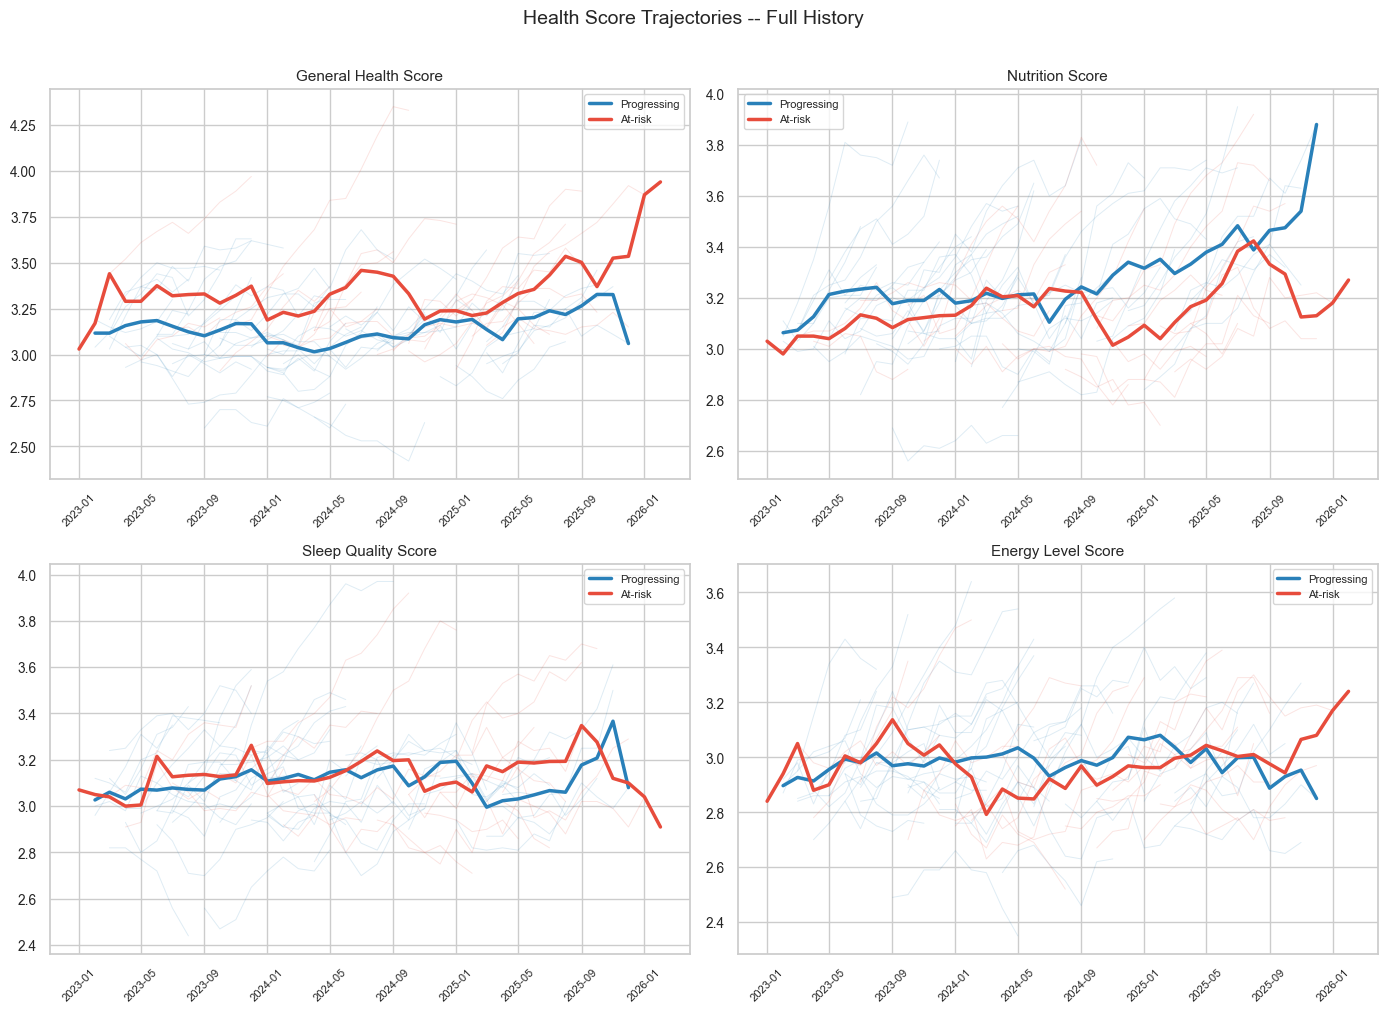

In [17]:
# -- 3a-i. Health score trajectories over full history ------------------------
health_traj = health_w.merge(
    residents_clean[["resident_id", "at_risk"]], on="resident_id"
)
health_traj["month"] = health_traj["record_date"].dt.to_period("M")

score_cols = ["general_health_score", "nutrition_score", "sleep_quality_score", "energy_level_score"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(score_cols):
    ax = axes[i]
    for rid, grp in health_traj.groupby("resident_id"):
        label_val = label_map.get(rid, 0)
        grp_sorted = grp.sort_values("record_date")
        ax.plot(grp_sorted["record_date"], grp_sorted[col],
                color=COLORS[label_val], alpha=0.15, linewidth=0.7)

    for label_val in [0, 1]:
        subset = health_traj[health_traj["at_risk"] == label_val]
        monthly_avg = subset.groupby("record_date")[col].mean().sort_index()
        ax.plot(monthly_avg.index, monthly_avg.values,
                color=COLORS[label_val], linewidth=2.5, label=LABELS[label_val])

    ax.set_title(col.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(fontsize=8)

fig.suptitle("Health Score Trajectories -- Full History", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

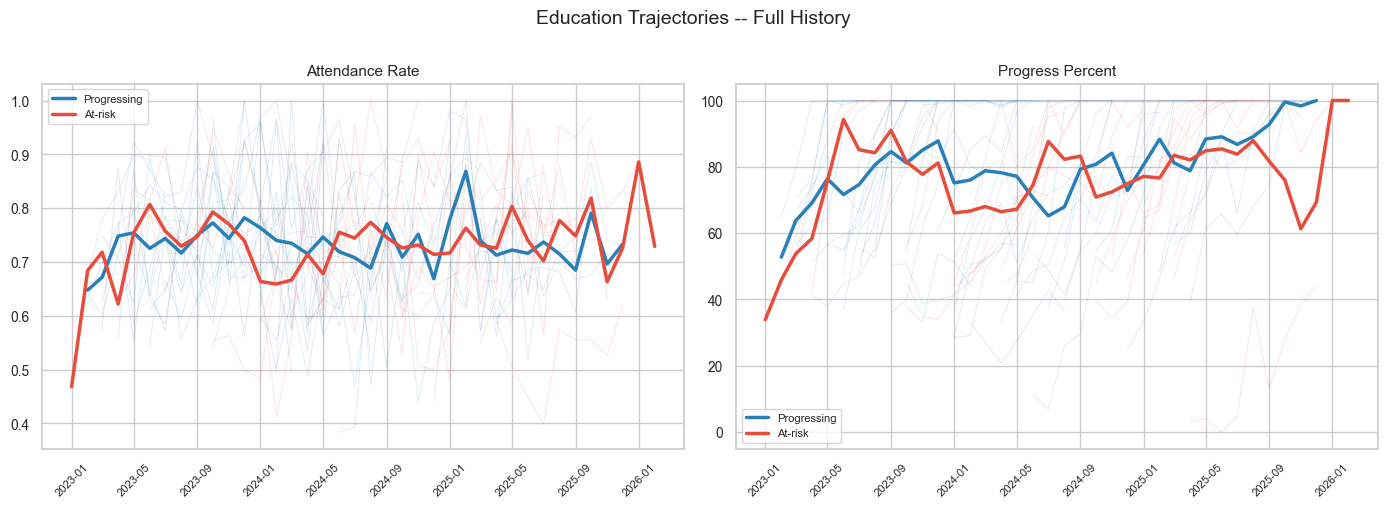

In [18]:
# -- 3a-ii. Education trajectories over full history --------------------------
edu_traj = edu_w.merge(
    residents_clean[["resident_id", "at_risk"]], on="resident_id"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(["attendance_rate", "progress_percent"]):
    ax = axes[i]
    for rid, grp in edu_traj.groupby("resident_id"):
        label_val = label_map.get(rid, 0)
        grp_sorted = grp.sort_values("record_date")
        ax.plot(grp_sorted["record_date"], grp_sorted[col],
                color=COLORS[label_val], alpha=0.15, linewidth=0.7)

    for label_val in [0, 1]:
        subset = edu_traj[edu_traj["at_risk"] == label_val]
        monthly_avg = subset.groupby("record_date")[col].mean().sort_index()
        ax.plot(monthly_avg.index, monthly_avg.values,
                color=COLORS[label_val], linewidth=2.5, label=LABELS[label_val])

    ax.set_title(col.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(fontsize=8)

fig.suptitle("Education Trajectories -- Full History", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

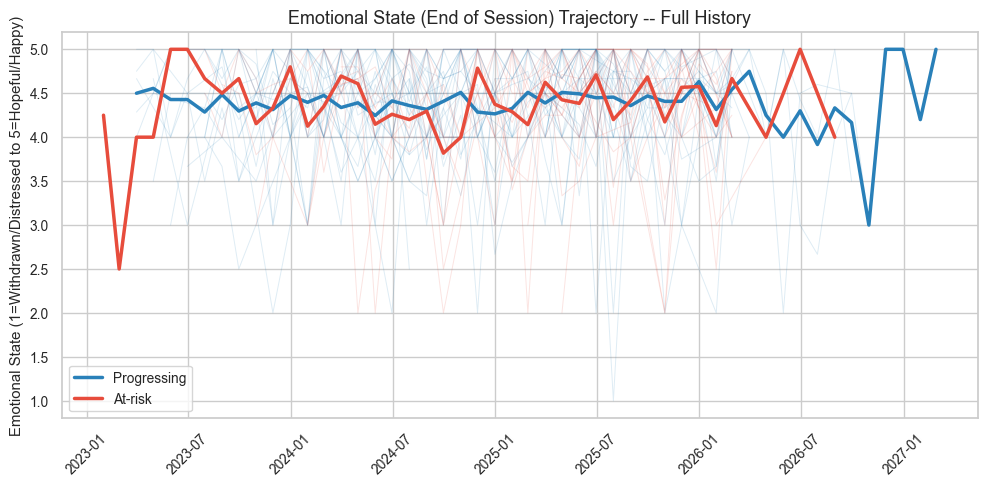

In [19]:
# -- 3a-iii. Emotional state trajectory over full history ---------------------
rec_traj = rec_w.merge(
    residents_clean[["resident_id", "at_risk"]], on="resident_id"
).copy()
rec_traj["emotional_end_encoded"] = rec_traj["emotional_state_end"].map(EMOTIONAL_STATE_MAP)

fig, ax = plt.subplots(figsize=(10, 5))

for rid, grp in rec_traj.groupby("resident_id"):
    label_val = label_map.get(rid, 0)
    grp_sorted = grp.sort_values("session_date")
    monthly = grp_sorted.set_index("session_date")["emotional_end_encoded"].resample("ME").mean().dropna()
    ax.plot(monthly.index, monthly.values,
            color=COLORS[label_val], alpha=0.15, linewidth=0.7)

for label_val in [0, 1]:
    subset = rec_traj[rec_traj["at_risk"] == label_val].copy()
    monthly_avg = subset.set_index("session_date")["emotional_end_encoded"].resample("ME").mean().dropna()
    ax.plot(monthly_avg.index, monthly_avg.values,
            color=COLORS[label_val], linewidth=2.5, label=LABELS[label_val])

ax.set_title("Emotional State (End of Session) Trajectory -- Full History", fontsize=13)
ax.set_ylabel("Emotional State (1=Withdrawn/Distressed to 5=Hopeful/Happy)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Univariate Analysis -- Descriptive Statistics

A descriptive statistics table for all numeric features, followed by skewness and outlier counts. This gives a quick numerical summary before visualizing distributions.

In [20]:
# -- 3b. Descriptive statistics for all numeric features ----------------------
numeric_features = merged.select_dtypes(include=[np.number]).columns.drop("at_risk")

desc = merged[numeric_features].describe().T
desc["skew"] = merged[numeric_features].skew()
desc["outliers"] = merged[numeric_features].apply(
    lambda col: ((col < col.quantile(0.25) - 1.5 * (col.quantile(0.75) - col.quantile(0.25))) |
                 (col > col.quantile(0.75) + 1.5 * (col.quantile(0.75) - col.quantile(0.25)))).sum()
)

print(f"Descriptive statistics for {len(numeric_features)} numeric features:")
desc.round(2)

Descriptive statistics for 95 numeric features:


,count,mean,std,min,25%,50%,75%,max,skew,outliers
sub_cat_orphaned,60.0,0.17,0.38,0.00,0.00,0.00,0.00,1.00,1.84,10
sub_cat_trafficked,60.0,0.18,0.39,0.00,0.00,0.00,0.00,1.00,1.68,11
sub_cat_child_labor,60.0,0.17,0.38,0.00,0.00,0.00,0.00,1.00,1.84,10
sub_cat_physical_abuse,60.0,0.12,0.32,0.00,0.00,0.00,0.00,1.00,2.45,7
sub_cat_sexual_abuse,60.0,0.25,0.44,0.00,0.00,0.00,0.25,1.00,1.18,15
...,...,...,...,...,...,...,...,...,...,...
concerns_flagged_prop,60.0,0.25,0.08,0.14,0.19,0.23,0.29,0.55,1.26,1
referral_made_prop,60.0,0.15,0.06,0.00,0.10,0.14,0.19,0.35,0.72,1
session_type_Individual,60.0,0.64,0.09,0.43,0.57,0.63,0.69,0.89,0.34,1
session_type_Group,60.0,0.36,0.09,0.11,0.31,0.37,0.43,0.57,-0.34,1


### 3c. Bivariate Analysis -- Distributions by At-Risk Status

Violin plots split by `at_risk` status. With 60 residents, box plots and violin plots are far more informative than histograms -- they show median, spread, outliers, and distribution shape even with small groups. Each plot shows whether the feature separates the two classes.

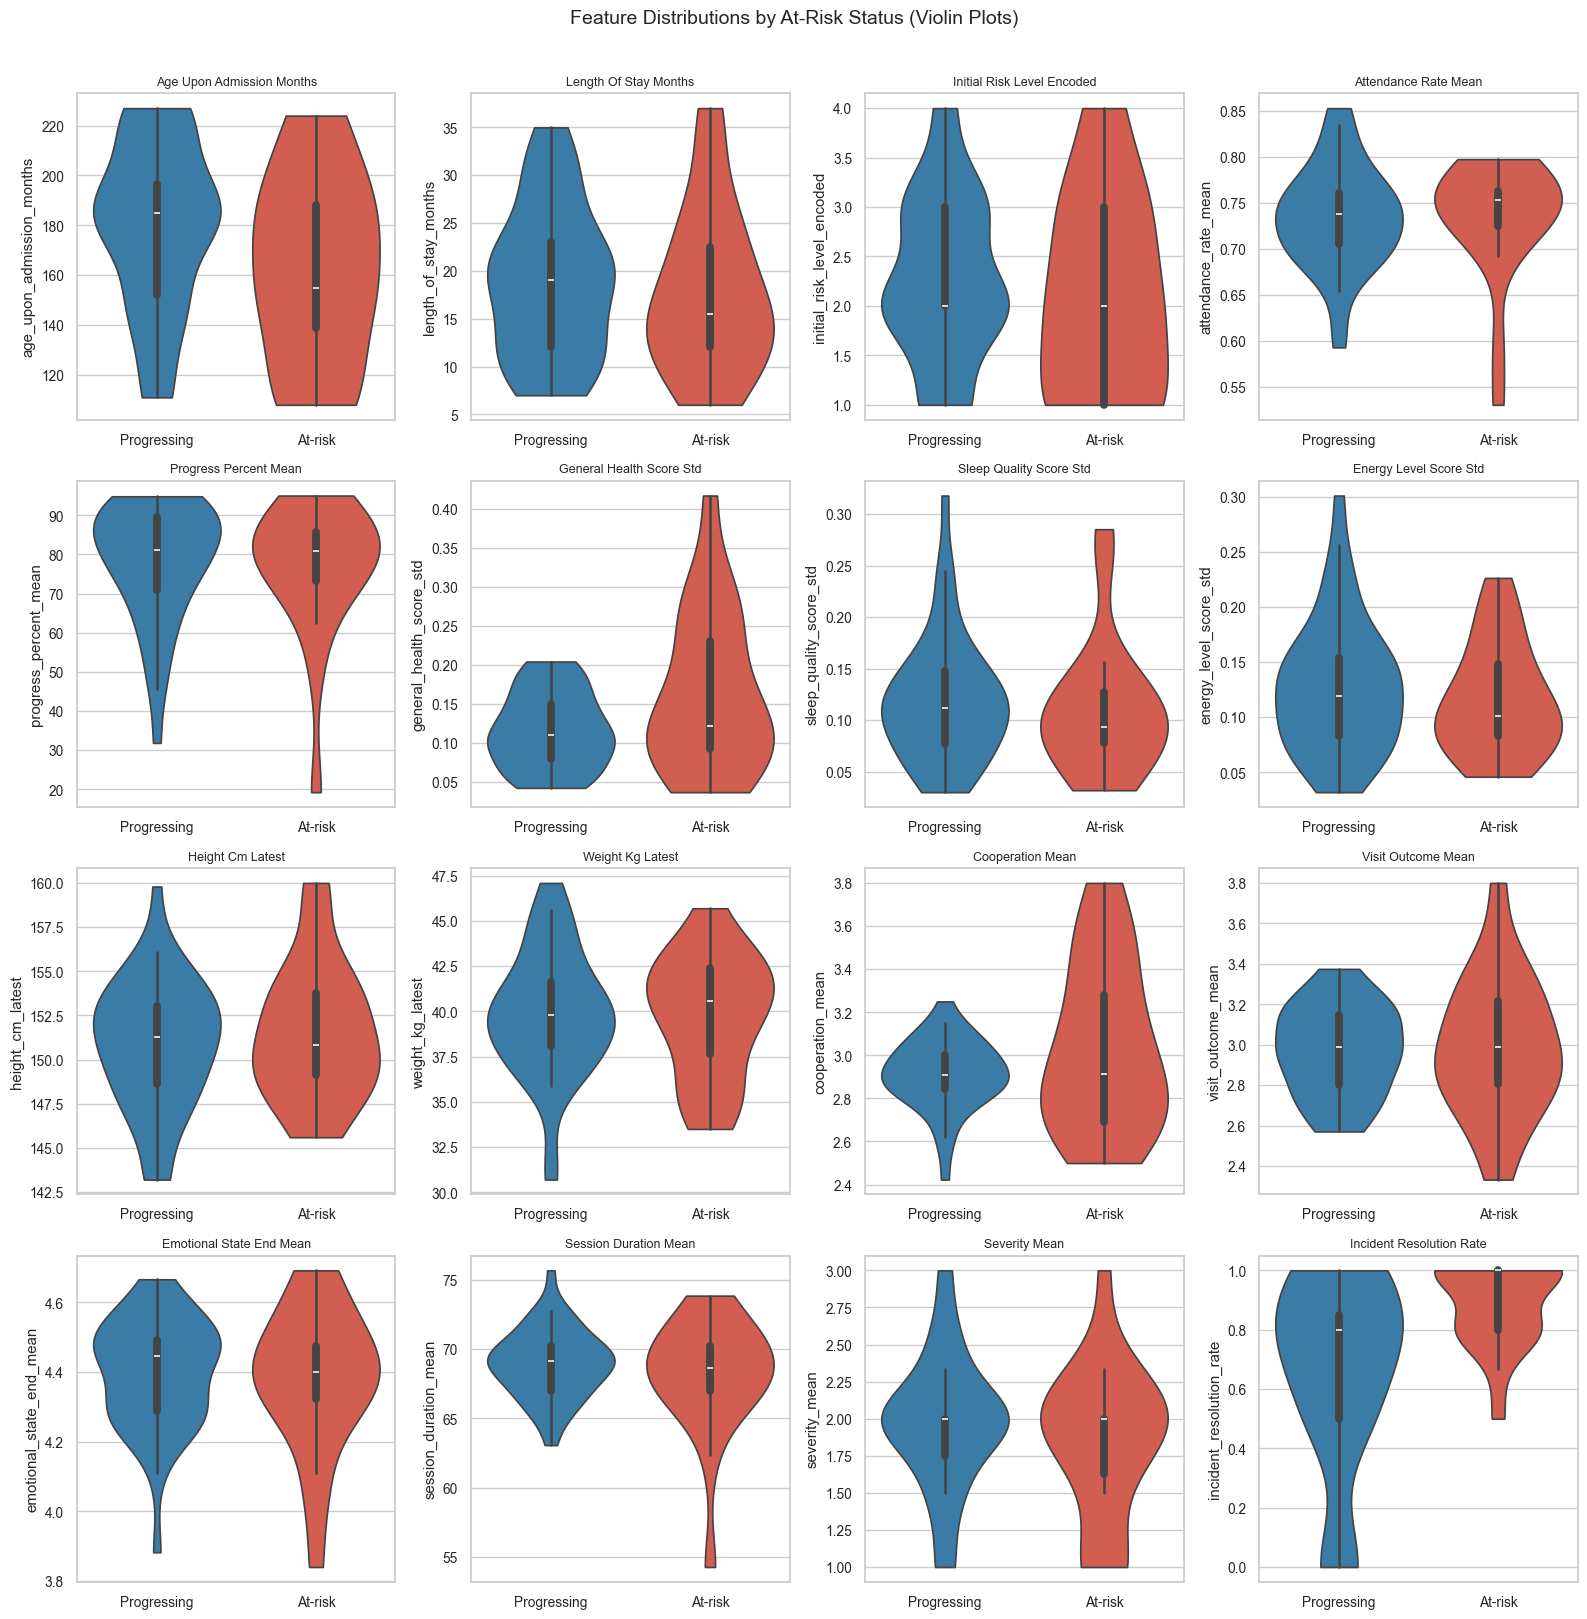

In [21]:
# -- 3c-i. Violin plots for continuous features split by at_risk ---------------
continuous_features = [
    "age_upon_admission_months", "length_of_stay_months", "initial_risk_level_encoded",
    "attendance_rate_mean", "progress_percent_mean",
    "general_health_score_std", "sleep_quality_score_std", "energy_level_score_std",
    "height_cm_latest", "weight_kg_latest",
    "cooperation_mean", "visit_outcome_mean",
    "emotional_state_end_mean", "session_duration_mean",
    "severity_mean", "incident_resolution_rate",
]
continuous_features = [f for f in continuous_features if f in merged.columns]

plot_df = merged.copy()
plot_df["Status"] = plot_df["at_risk"].map(LABELS)

n_cols = 4
n_rows = (len(continuous_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(continuous_features):
    ax = axes[i]
    sns.violinplot(
        data=plot_df, x="Status", y=col, hue="Status", ax=ax,
        order=["Progressing", "At-risk"],
        palette={"Progressing": COLORS[0], "At-risk": COLORS[1]},
        inner="box", cut=0, density_norm="width", legend=False
    )
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by At-Risk Status (Violin Plots)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

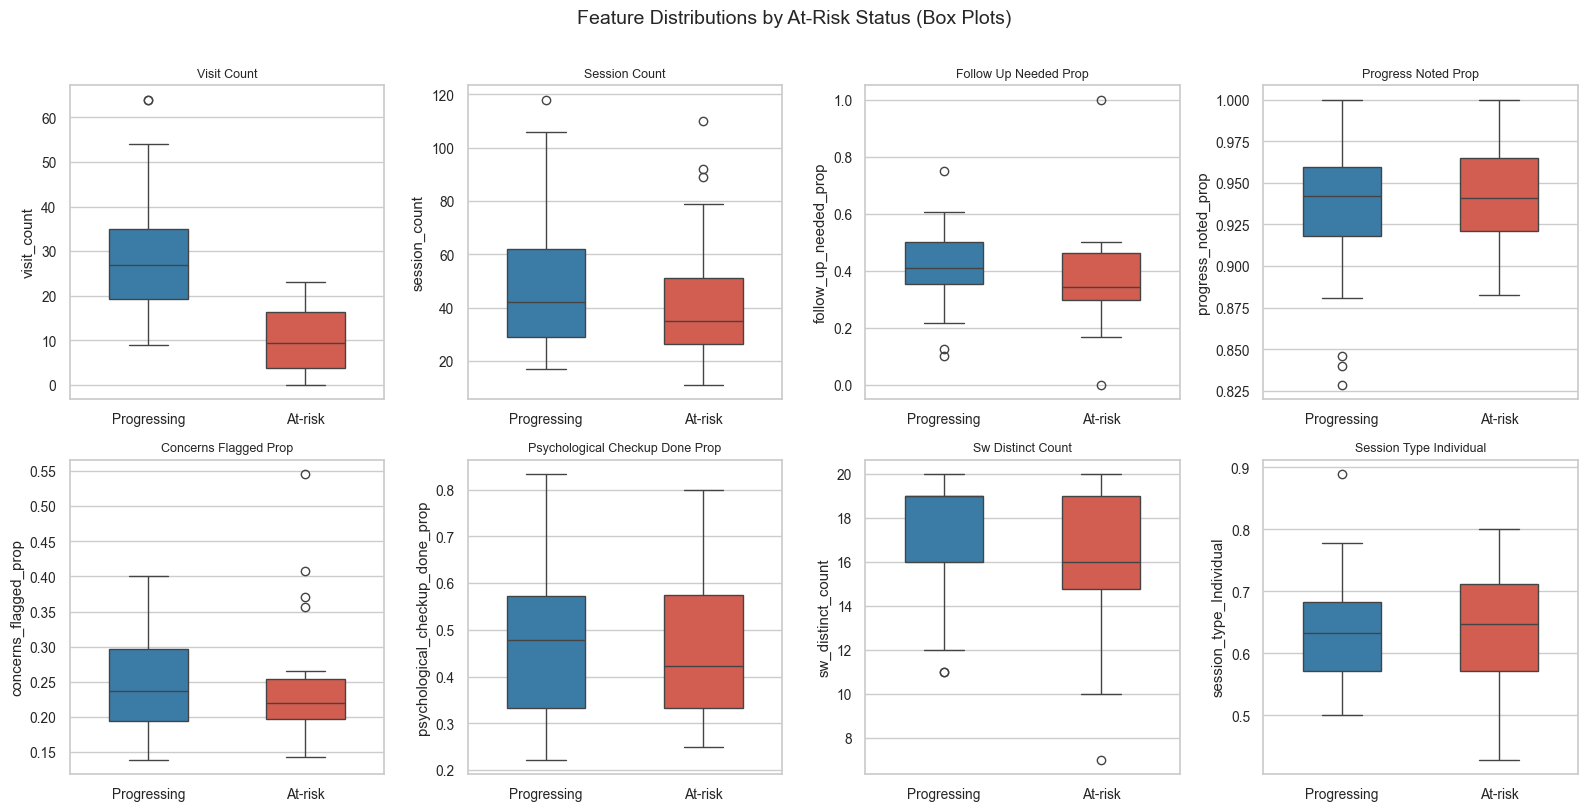

In [22]:
# -- 3c-ii. Box plots for count, recency, and proportion features --------------
boxplot_features = [
    "visit_count", "session_count",
    "visit_days_since_last", "session_days_since_last",
    "incident_days_since_last", "dental_checkup_done_days_since",
    "safety_concerns_days_since", "concerns_flagged_days_since",
    "follow_up_needed_prop", "progress_noted_prop", "concerns_flagged_prop",
    "psychological_checkup_done_prop",
    "sw_distinct_count", "session_type_Individual",
]
boxplot_features = [f for f in boxplot_features if f in merged.columns]

plot_df = merged.copy()
plot_df["Status"] = plot_df["at_risk"].map(LABELS)

n_cols = 4
n_rows = (len(boxplot_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(boxplot_features):
    ax = axes[i]
    sns.boxplot(
        data=plot_df, x="Status", y=col, hue="Status", ax=ax,
        order=["Progressing", "At-risk"],
        palette={"Progressing": COLORS[0], "At-risk": COLORS[1]},
        width=0.5, legend=False
    )
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by At-Risk Status (Box Plots)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3d. Bivariate Analysis -- Plan Status by At-Risk Status

Intervention plan status is an ordinal feature with a small number of levels. A grouped bar chart is more appropriate here than a violin plot -- it shows how the distribution of plan statuses differs between the two groups.

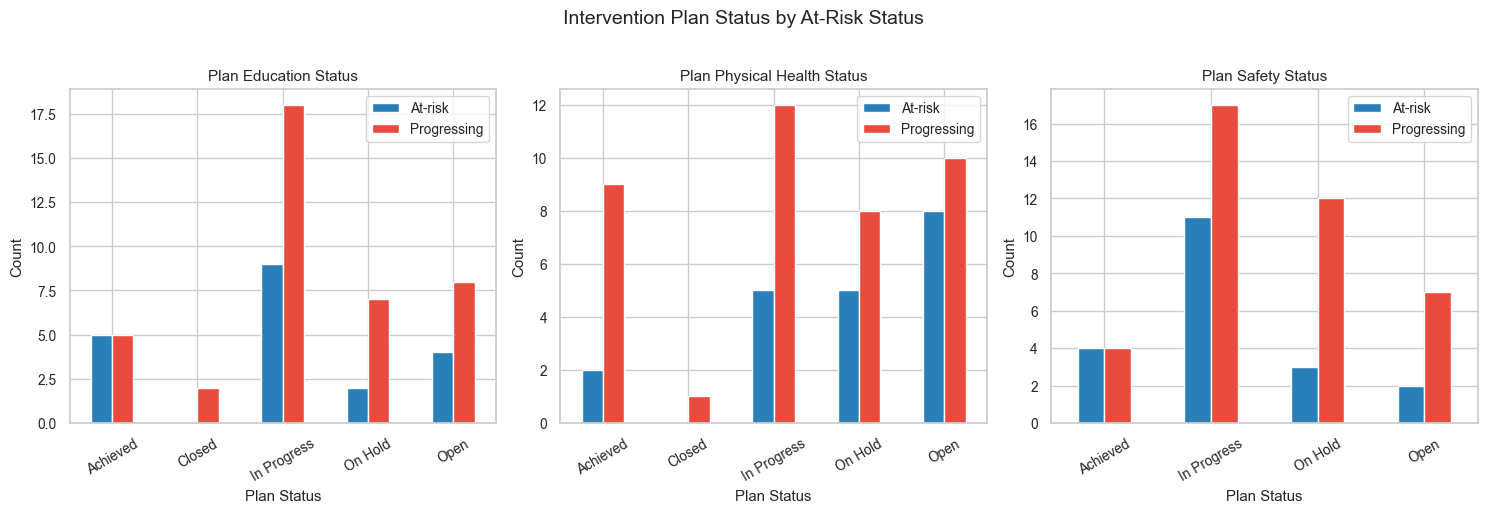

In [23]:
# -- 3d. Plan status distribution by at-risk status ---------------------------
plan_cols = ["plan_education_status", "plan_physical_health_status", "plan_safety_status"]
plan_cols = [c for c in plan_cols if c in merged.columns]
status_labels = {v: k for k, v in PLAN_STATUS_MAP.items()}

fig, axes = plt.subplots(1, len(plan_cols), figsize=(5 * len(plan_cols), 5))
if len(plan_cols) == 1:
    axes = [axes]

for i, col in enumerate(plan_cols):
    ax = axes[i]
    ct = pd.crosstab(merged[col].map(status_labels), merged["at_risk"].map(LABELS))
    ct.plot.bar(ax=ax, color=[COLORS[0], COLORS[1]], edgecolor="white", rot=30)
    ax.set_title(col.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("Plan Status")
    ax.set_ylabel("Count")
    ax.legend(title="")

fig.suptitle("Intervention Plan Status by At-Risk Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3e. Bivariate Analysis -- At-Risk Rate by Binary Features

For binary resident features (family flags, subcategories), we show the at-risk rate difference when the flag is True vs False. This surfaces whether certain subgroups have disproportionately high or low risk.

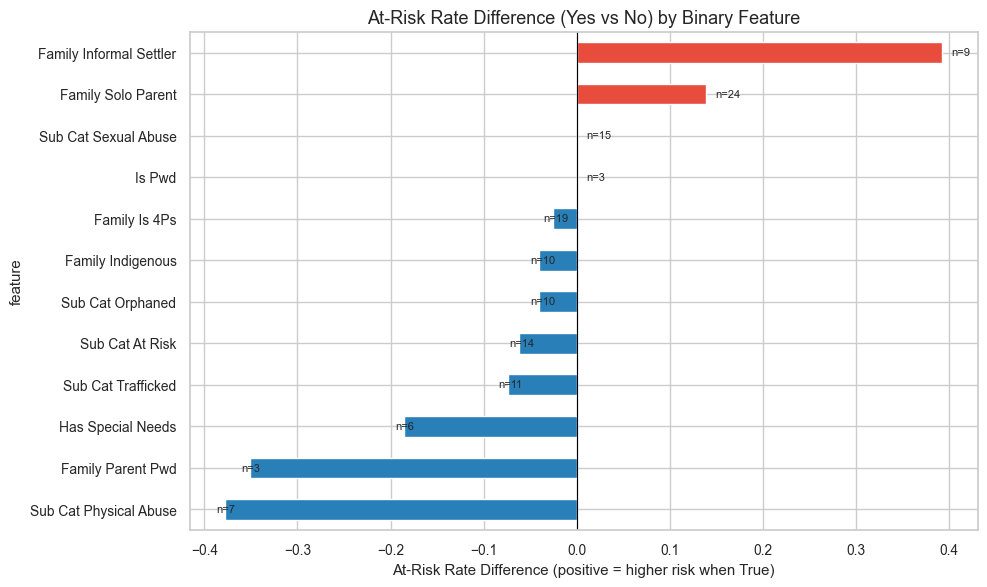

In [24]:
# -- 3e. At-risk rate by binary features --------------------------------------
binary_features = [
    "family_is_4ps", "family_solo_parent", "family_indigenous",
    "family_parent_pwd", "family_informal_settler",
    "is_pwd", "has_special_needs",
    "sub_cat_orphaned", "sub_cat_trafficked", "sub_cat_physical_abuse",
    "sub_cat_sexual_abuse", "sub_cat_at_risk",
]
binary_features = [f for f in binary_features if f in merged.columns]

rates = []
for col in binary_features:
    for val in [0, 1]:
        subset = merged[merged[col] == val]
        if len(subset) > 0:
            rates.append({
                "feature": col.replace("_", " ").title(),
                "value": "Yes" if val == 1 else "No",
                "at_risk_rate": subset["at_risk"].mean(),
                "n": len(subset),
            })

rates_df = pd.DataFrame(rates)

fig, ax = plt.subplots(figsize=(10, max(6, len(binary_features) * 0.5)))

yes_rates = rates_df[rates_df["value"] == "Yes"].set_index("feature")["at_risk_rate"]
no_rates = rates_df[rates_df["value"] == "No"].set_index("feature")["at_risk_rate"]
diff = (yes_rates - no_rates).sort_values()

colors = ["#e74c3c" if v > 0 else "#2980b9" for v in diff]
diff.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("At-Risk Rate Difference (Yes vs No) by Binary Feature", fontsize=13)
ax.set_xlabel("At-Risk Rate Difference (positive = higher risk when True)")
ax.axvline(0, color="black", linewidth=0.8)

yes_n = rates_df[rates_df["value"] == "Yes"].set_index("feature")["n"]
for j, feat in enumerate(diff.index):
    n = yes_n.get(feat, 0)
    ax.text(diff[feat] + 0.01 * (1 if diff[feat] >= 0 else -1), j,
            f"n={n}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### 3f. Correlation with Target -- Feature Importance Preview

A horizontal bar chart of Pearson correlation between each feature and `at_risk`. This replaces the traditional full correlation heatmap -- with many features the heatmap would be unreadable noise. The bar chart directly answers "which features are most associated with being at risk" and is the most useful single chart for guiding feature selection in later steps.

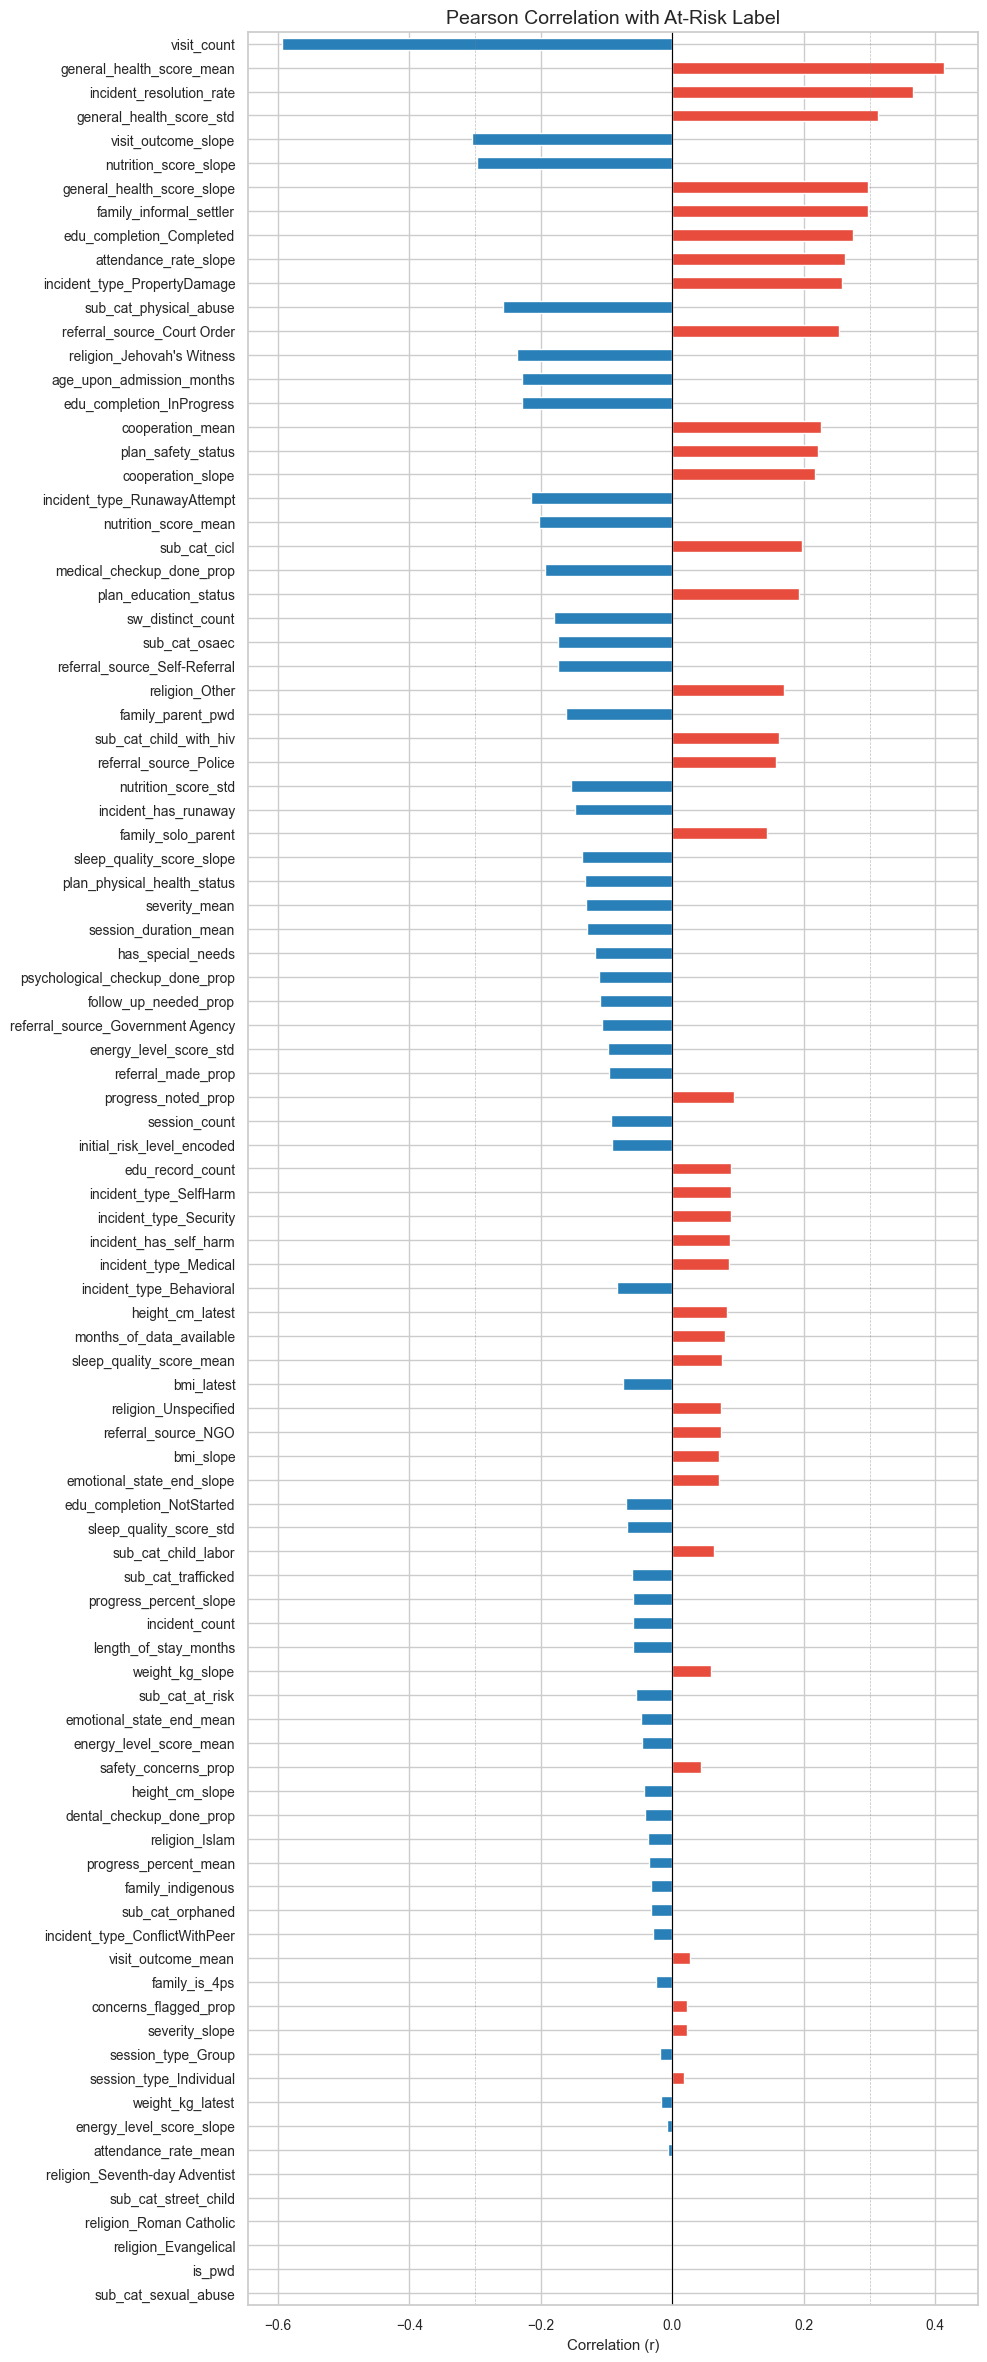


Top 10 features most correlated with at_risk:
  visit_count                                   r = -0.594  (lower risk)
  general_health_score_mean                     r = +0.414  (higher risk)
  incident_resolution_rate                      r = +0.366  (higher risk)
  general_health_score_std                      r = +0.313  (higher risk)
  visit_outcome_slope                           r = -0.305  (lower risk)
  nutrition_score_slope                         r = -0.298  (lower risk)
  general_health_score_slope                    r = +0.297  (higher risk)
  family_informal_settler                       r = +0.297  (higher risk)
  edu_completion_Completed                      r = +0.275  (higher risk)
  attendance_rate_slope                         r = +0.263  (higher risk)


In [25]:
# -- 3f. Correlation with at_risk (replaces full heatmap) ---------------------
numeric_features = merged.select_dtypes(include=[np.number]).columns.drop("at_risk")

corr_with_target = (
    merged[numeric_features.tolist() + ["at_risk"]]
    .corr()["at_risk"]
    .drop("at_risk")
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(8, len(corr_with_target) * 0.25)))
colors = ["#e74c3c" if v > 0 else "#2980b9" for v in corr_with_target]
corr_with_target.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Pearson Correlation with At-Risk Label", fontsize=14)
ax.set_xlabel("Correlation (r)")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.3, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax.axvline(-0.3, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

print("\nTop 10 features most correlated with at_risk:")
top10 = corr_with_target.abs().sort_values(ascending=False).head(10)
for feat in top10.index:
    r = corr_with_target[feat]
    direction = "higher risk" if r > 0 else "lower risk"
    print(f"  {feat:45s} r = {r:+.3f}  ({direction})")

### Exploration Summary

Key takeaways from the exploration:

- **Trajectory plots** validate that the slope features capture real divergence between at-risk and progressing residents in health, education, and emotional trajectories.
- **Violin/box plots** reveal which engineered features show the clearest separation between the two groups, guiding feature selection in later steps.
- **Correlation with target** provides a ranked list of features by predictive relevance, highlighting which dimensions (health volatility, cooperation trends, session patterns, etc.) are most informative for the at-risk classification.

These findings will inform feature selection in Step 6 and model interpretation in Step 5.

## Step 2 (continued) -- Distribution Transforms

Now that exploration has revealed which features are skewed and which carry little variance, we apply the remaining Ch 7 pipeline steps: Yeo-Johnson skew correction and low-variance removal. These transforms are intentionally placed after EDA so the exploration reflects the raw feature distributions, and the transforms are informed by what we observed.

In [26]:
# -- Post-EDA transforms: skew correction and low-variance removal ------------
final_df = merged.copy()

final_df = skew_correct(final_df)
print()
final_df = drop_low_variance(final_df)

print(f"Final shape after transforms: {final_df.shape}")

skew_correct: transformed 46 columns (threshold=1.0):
  sub_cat_orphaned (skew=1.84)
  sub_cat_trafficked (skew=1.68)
  sub_cat_child_labor (skew=1.84)
  sub_cat_physical_abuse (skew=2.45)
  sub_cat_sexual_abuse (skew=1.18)
  sub_cat_osaec (skew=2.21)
  sub_cat_cicl (skew=2.01)
  sub_cat_at_risk (skew=1.29)
  sub_cat_street_child (skew=2.01)
  sub_cat_child_with_hiv (skew=4.24)
  is_pwd (skew=4.24)
  has_special_needs (skew=2.74)
  family_indigenous (skew=1.84)
  family_parent_pwd (skew=4.24)
  family_informal_settler (skew=2.01)
  referral_source_Court Order (skew=1.84)
  referral_source_Government Agency (skew=1.08)
  referral_source_NGO (skew=2.45)
  referral_source_Police (skew=1.84)
  referral_source_Self-Referral (skew=2.21)
  religion_Evangelical (skew=1.54)
  religion_Islam (skew=2.45)
  religion_Jehovah's Witness (skew=2.74)
  religion_Other (skew=3.09)
  religion_Roman Catholic (skew=2.74)
  religion_Seventh-day Adventist (skew=2.01)
  religion_Unspecified (skew=2.45)
  atten

### 2.9 Final Dataset Validation

Before saving, we verify the dataset is clean: no missing values, correct shape, target distribution confirmed, and no leakage columns present.

In [27]:
# -- Final dataset validation --------------------------------------------------
print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print(f"\nShape: {final_df.shape[0]} rows x {final_df.shape[1]} columns")

print(f"\nClass distribution of at_risk:")
dist = final_df["at_risk"].value_counts()
for label, count in dist.items():
    pct = count / len(final_df) * 100
    name = "At-risk" if label == 1 else "Progressing"
    print(f"  {name} ({label}): {count} ({pct:.1f}%)")

print(f"\nNumber of features: {final_df.shape[1] - 1}")

remaining_missing = final_df.isna().sum().sum()
print(f"\nRemaining missing values: {remaining_missing}")

leakage_check = [c for c in LEAKAGE_COLS if c in final_df.columns]
leakage_check += [c for c in ["reintegration_status", "resident_id"] if c in final_df.columns]
if leakage_check:
    print(f"\nLEAKAGE WARNING: {leakage_check}")
else:
    print("\nNo leakage columns detected.")

print(f"\nTarget column: 'at_risk' is {'present' if 'at_risk' in final_df.columns else 'MISSING'}")

FINAL DATASET VALIDATION

Shape: 60 rows x 38 columns

Class distribution of at_risk:
  Progressing (0): 40 (66.7%)
  At-risk (1): 20 (33.3%)

Number of features: 37

Remaining missing values: 0

No leakage columns detected.

Target column: 'at_risk' is present


In [28]:
# -- Save final dataset --------------------------------------------------------
output_path = DATA_DIR / "resident_risk_df.csv"
final_df.to_csv(output_path, index=False)
print(f"Saved: {output_path} -- {final_df.shape[0]} rows x {final_df.shape[1]} columns")

Saved: dataset\resident_risk_df.csv -- 60 rows x 38 columns


## Step 4 -- Modeling

Two parallel modeling tracks are run, following the prediction vs. explanation distinction from Ch. 9-11 of the textbook.

- **Track A (Explanatory):** An untuned logistic regression that produces interpretable coefficients and odds ratios. The goal is to understand which features are most associated with at-risk status -- useful for caseworker training and policy decisions.
- **Track B (Predictive):** Three classifiers tuned with GridSearchCV and stratified 5-fold cross-validation, optimized for ROC AUC. The goal is a reliable score for caseload prioritization.

Before splitting the data, Variance Inflation Factor (VIF) pruning removes features with excessive multicollinearity (threshold = 5). A stratified 80/20 train/test split preserves the class ratio in both halves. Because all features are already numeric after Step 2 transforms, the preprocessor applies StandardScaler only (no one-hot encoding needed).

In [29]:
# -- 4a. Variance Inflation Factor (VIF) pruning (Ch. 10, 16) ---------------
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Allow this section to run after a kernel restart
try:
    final_df
except NameError:
    from pathlib import Path
    import pandas as pd
    import numpy as np
    DATA_DIR = Path("dataset")
    final_df = pd.read_csv(DATA_DIR / "resident_risk_df.csv")

TARGET = "at_risk"
all_features = [c for c in final_df.columns if c != TARGET]

def iterative_vif_pruning(df, features, threshold=5.0):
    """Iteratively drop the highest-VIF feature until all are below threshold."""
    remaining = features.copy()
    dropped = []
    while True:
        X_vif = df[remaining].assign(const=1)
        vifs = {col: variance_inflation_factor(X_vif.values, i) for i, col in enumerate(remaining)}
        worst_col = max(vifs, key=vifs.get)
        if vifs[worst_col] <= threshold:
            break
        print(f"  Dropping {worst_col} (VIF={vifs[worst_col]:.2f})")
        dropped.append((worst_col, vifs[worst_col]))
        remaining.remove(worst_col)
    return remaining, dropped

print("Iterative VIF pruning (threshold=5):")
vif_features, vif_dropped = iterative_vif_pruning(final_df, all_features)

print(f"\nFinal VIFs after pruning:")
X_final_vif = final_df[vif_features].assign(const=1)
for i, col in enumerate(vif_features):
    print(f"  {col}: {variance_inflation_factor(X_final_vif.values, i):.2f}")

print(f"\nDropped {len(vif_dropped)} feature(s): {[d[0] for d in vif_dropped]}")
print(f"Remaining features after VIF pruning: {len(vif_features)}")

Iterative VIF pruning (threshold=5):
  Dropping weight_kg_latest (VIF=924.93)
  Dropping months_of_data_available (VIF=185.03)
  Dropping initial_risk_level_encoded (VIF=11.22)
  Dropping length_of_stay_months (VIF=9.93)
  Dropping session_count (VIF=6.14)
  Dropping follow_up_needed_prop (VIF=5.51)

Final VIFs after pruning:
  family_is_4ps: 2.59
  family_solo_parent: 1.96
  age_upon_admission_months: 2.60
  progress_percent_slope: 2.83
  progress_percent_mean: 2.42
  edu_record_count: 3.46
  general_health_score_mean: 3.00
  nutrition_score_mean: 2.93
  sleep_quality_score_mean: 2.82
  energy_level_score_mean: 1.97
  height_cm_latest: 2.20
  bmi_latest: 2.28
  medical_checkup_done_prop: 1.47
  dental_checkup_done_prop: 1.77
  psychological_checkup_done_prop: 1.97
  incident_count: 2.39
  incident_has_runaway: 2.81
  incident_resolution_rate: 2.86
  severity_mean: 2.07
  severity_slope: 1.74
  plan_education_status: 1.98
  plan_physical_health_status: 1.78
  plan_safety_status: 1.76
 

In [30]:
# -- 4b. Prepare features and train/test split ----------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

X = final_df[vif_features].copy()
y = final_df[TARGET].copy()

# 80/20 stratified split -- test set reserved for final evaluation only
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessor: StandardScaler only (all features are already numeric after Step 2 transforms)
preprocessor = Pipeline([('scaler', StandardScaler())])

# Stratified 5-fold CV preserves the 2:1 class ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1': 'f1', 'roc_auc': 'roc_auc'}

print(f"Train set: {X_train.shape[0]} residents ({y_train.mean():.0%} at-risk)")
print(f"Test set:  {X_test.shape[0]} residents ({y_test.mean():.0%} at-risk) -- reserved for final evaluation")
print(f"CV strategy: Stratified 5-fold")
print(f"Features ({len(vif_features)}): {vif_features}")

Train set: 48 residents (33% at-risk)
Test set:  12 residents (33% at-risk) -- reserved for final evaluation
CV strategy: Stratified 5-fold
Features (31): ['family_is_4ps', 'family_solo_parent', 'age_upon_admission_months', 'progress_percent_slope', 'progress_percent_mean', 'edu_record_count', 'general_health_score_mean', 'nutrition_score_mean', 'sleep_quality_score_mean', 'energy_level_score_mean', 'height_cm_latest', 'bmi_latest', 'medical_checkup_done_prop', 'dental_checkup_done_prop', 'psychological_checkup_done_prop', 'incident_count', 'incident_has_runaway', 'incident_resolution_rate', 'severity_mean', 'severity_slope', 'plan_education_status', 'plan_physical_health_status', 'plan_safety_status', 'visit_count', 'cooperation_slope', 'visit_outcome_mean', 'visit_outcome_slope', 'safety_concerns_prop', 'emotional_state_end_mean', 'session_duration_mean', 'sw_distinct_count']


In [31]:
# -- 4c. Track A: Explanatory logistic regression (stratified k-fold) -------
lr_explain = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

lr_cv_results = cross_validate(lr_explain, X_train, y_train, cv=cv, scoring=scoring)

print("Track A -- Explanatory Logistic Regression (5-fold stratified CV on training data):")
print(f"  F1:      {lr_cv_results['test_f1'].mean():.3f} +/- {lr_cv_results['test_f1'].std():.3f}")
print(f"  AUC-ROC: {lr_cv_results['test_roc_auc'].mean():.3f} +/- {lr_cv_results['test_roc_auc'].std():.3f}")

# Fit on full training set to extract coefficients
lr_explain.fit(X_train, y_train)

coefs = lr_explain.named_steps['clf'].coef_[0]
odds_ratios = np.exp(coefs)

odds_df = pd.DataFrame({
    'feature': vif_features,
    'coefficient': coefs,
    'odds_ratio': odds_ratios,
    'direction': ['Increases risk' if c > 0 else 'Decreases risk' for c in coefs],
}).sort_values('coefficient', key=abs, ascending=False)

print("\nOdds Ratios (sorted by absolute effect size):")
print(odds_df.to_string(index=False))

Track A -- Explanatory Logistic Regression (5-fold stratified CV on training data):
  F1:      0.720 +/- 0.221
  AUC-ROC: 0.898 +/- 0.122

Odds Ratios (sorted by absolute effect size):
                        feature  coefficient  odds_ratio      direction
                    visit_count    -1.388140    0.249539 Decreases risk
      general_health_score_mean     1.039517    2.827850 Increases risk
              cooperation_slope     0.838275    2.312375 Increases risk
           nutrition_score_mean    -0.824697    0.438368 Decreases risk
          plan_education_status     0.681488    1.976817 Increases risk
      medical_checkup_done_prop    -0.590310    0.554156 Decreases risk
                  family_is_4ps    -0.583097    0.558167 Decreases risk
      age_upon_admission_months    -0.555679    0.573683 Decreases risk
             plan_safety_status     0.530177    1.699233 Increases risk
               edu_record_count    -0.451362    0.636760 Decreases risk
               height_c

In [32]:
# -- 4d. Track B: Train and compare three classifiers (GridSearchCV) ---------
import warnings
warnings.filterwarnings('ignore')

# 1. Logistic Regression (tuned)
lr_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid={'clf__C': [0.01, 0.1, 1, 10]},
    cv=cv, scoring='roc_auc', refit=True,
)
lr_grid.fit(X_train, y_train)

# 2. Decision Tree (tuned)
dt_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('clf', DecisionTreeClassifier(random_state=42))]),
    param_grid={'clf__max_depth': [2, 3, 4, 5], 'clf__min_samples_leaf': [2, 3, 5]},
    cv=cv, scoring='roc_auc', refit=True,
)
dt_grid.fit(X_train, y_train)

# 3. Gradient Boosting (tuned)
gb_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('clf', GradientBoostingClassifier(random_state=42))]),
    param_grid={
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [2, 3],
        'clf__learning_rate': [0.05, 0.1],
    },
    cv=cv, scoring='roc_auc', refit=True,
)
gb_grid.fit(X_train, y_train)

models = {
    'Logistic Regression': lr_grid,
    'Decision Tree': dt_grid,
    'Gradient Boosting': gb_grid,
}

print("Track B -- Cross-Validated Model Comparison (5-fold stratified):")
header = f"{'Model':<25} {'Best Params':<45} {'CV AUC':>8} {'CV F1':>14}"
print(header)
print("-" * len(header))

for name, grid in models.items():
    f1_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    params_str = str({k.replace('clf__', ''): v for k, v in grid.best_params_.items()})
    print(
        f"{name:<25} {params_str:<45} "
        f"{grid.best_score_:>8.3f} "
        f"{f1_cv['test_f1'].mean():>6.3f} +/- {f1_cv['test_f1'].std():.3f}"
    )

Track B -- Cross-Validated Model Comparison (5-fold stratified):
Model                     Best Params                                     CV AUC          CV F1
-----------------------------------------------------------------------------------------------
Logistic Regression       {'C': 0.1}                                       0.898  0.520 +/- 0.147
Decision Tree             {'max_depth': 2, 'min_samples_leaf': 2}          0.915  0.864 +/- 0.080
Gradient Boosting         {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}    0.917  0.737 +/- 0.060


In [33]:
# -- 4e. Select best model and evaluate on held-out test set ---------------
best_name = max(models, key=lambda k: models[k].best_score_)
best_model = models[best_name].best_estimator_

print(f"Best model by CV AUC-ROC: {best_name} (AUC={models[best_name].best_score_:.3f})")
print(f"Best parameters: {models[best_name].best_params_}")

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_f1 = f1_score(y_test, y_pred)
test_labels = y_test.unique()
test_auc = roc_auc_score(y_test, y_prob) if len(test_labels) > 1 else float('nan')

print(f"\nHeld-out test set results ({len(y_test)} residents):")
print(f"  F1:      {test_f1:.3f}")
print(f"  AUC-ROC: {test_auc:.3f}")
print(f"\nConfusion matrix (rows=actual, cols=predicted):")
cm = confusion_matrix(y_test, y_pred)
print(f"  Progressing (0): {cm[0]}")
print(f"  At-risk     (1): {cm[1]}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Progressing', 'At-risk']))

Best model by CV AUC-ROC: Gradient Boosting (AUC=0.917)
Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 50}

Held-out test set results (12 residents):
  F1:      0.857
  AUC-ROC: 0.844

Confusion matrix (rows=actual, cols=predicted):
  Progressing (0): [8 0]
  At-risk     (1): [1 3]

Classification report:
              precision    recall  f1-score   support

 Progressing       0.89      1.00      0.94         8
     At-risk       1.00      0.75      0.86         4

    accuracy                           0.92        12
   macro avg       0.94      0.88      0.90        12
weighted avg       0.93      0.92      0.91        12



## Step 5 -- Evaluation and Selection

### Model Selection Rationale
The best predictive model is selected by CV AUC-ROC, the primary metric for this pipeline. AUC-ROC measures how well the model separates at-risk from progressing residents regardless of threshold, which is more informative than accuracy when the class ratio is 2:1. Recall for the at-risk class is the secondary concern -- a missed at-risk resident (false negative) is more costly to the organization than a false alarm.

### Track A vs. Track B Purpose
- **Track A (Explanatory LR):** Tells caseworkers and program managers *why* a resident is flagged. Odds ratios quantify which factors are most associated with regression. This supports staff training and program design decisions.
- **Track B (Predictive):** Produces reliable risk scores for caseload triage. The best model's scores are binned into Low/Medium/High tiers so caseworkers can prioritize who needs immediate attention this week.

### Business Interpretation
With N=60, all CV metrics should be interpreted with caution -- variance is high. A test AUC above 0.70 indicates the model is meaningfully separating classes. The organization should use risk tiers directionally, not as precise probability estimates.

In [34]:
# -- 5a. Cross-validated model comparison table ----------------------------
comparison_rows = []

# Track A: Explanatory LR (from cross_validate results)
comparison_rows.append({
    'Track': 'A (Explanatory)',
    'Model': 'Logistic Regression (untuned)',
    'CV AUC-ROC (mean)': lr_cv_results['test_roc_auc'].mean(),
    'CV AUC-ROC (std)': lr_cv_results['test_roc_auc'].std(),
    'CV F1 (mean)': lr_cv_results['test_f1'].mean(),
    'CV F1 (std)': lr_cv_results['test_f1'].std(),
})

# Track B: All three tuned models
for name, grid in models.items():
    f1_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    auc_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv,
                            scoring={'roc_auc': 'roc_auc'})
    comparison_rows.append({
        'Track': 'B (Predictive)',
        'Model': name,
        'CV AUC-ROC (mean)': auc_cv['test_roc_auc'].mean(),
        'CV AUC-ROC (std)': auc_cv['test_roc_auc'].std(),
        'CV F1 (mean)': f1_cv['test_f1'].mean(),
        'CV F1 (std)': f1_cv['test_f1'].std(),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['CV AUC-ROC'] = comparison_df.apply(
    lambda r: f"{r['CV AUC-ROC (mean)']:.3f} +/- {r['CV AUC-ROC (std)']:.3f}", axis=1)
comparison_df['CV F1'] = comparison_df.apply(
    lambda r: f"{r['CV F1 (mean)']:.3f} +/- {r['CV F1 (std)']:.3f}", axis=1)

print('Cross-Validated Model Comparison (5-fold stratified, training data only):')
print(comparison_df[['Track', 'Model', 'CV AUC-ROC', 'CV F1']].to_string(index=False))

Cross-Validated Model Comparison (5-fold stratified, training data only):
          Track                         Model      CV AUC-ROC           CV F1
A (Explanatory) Logistic Regression (untuned) 0.898 +/- 0.122 0.720 +/- 0.221
 B (Predictive)           Logistic Regression 0.898 +/- 0.106 0.520 +/- 0.147
 B (Predictive)                 Decision Tree 0.915 +/- 0.050 0.864 +/- 0.080
 B (Predictive)             Gradient Boosting 0.917 +/- 0.099 0.737 +/- 0.060


In [35]:
# -- 5b. Resident risk ranking (predictive model) --------------------------
# Refit the best model on ALL data to produce risk scores for every resident
best_model_final = models[best_name].best_estimator_
best_model_final.fit(X, y)

risk_scores = best_model_final.predict_proba(X)[:, 1]

resident_risk_ranking = pd.DataFrame({
    'row_index': range(len(X)),
    'risk_score': risk_scores,
    'actual_at_risk': y.values,
})
resident_risk_ranking['risk_tier'] = pd.cut(
    resident_risk_ranking['risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)
resident_risk_ranking = resident_risk_ranking.sort_values('risk_score', ascending=False).reset_index(drop=True)

print(f"Resident Risk Ranking ({best_name}):")
print(f"Model trained on all {len(X)} residents for full-population scoring.\n")
print(resident_risk_ranking.to_string(index=False))

print(f"\nRisk tier distribution:")
tier_summary = resident_risk_ranking.groupby('risk_tier', observed=True).agg(
    count=('row_index', 'count'),
    actual_at_risk_rate=('actual_at_risk', 'mean')
).round(2)
print(tier_summary.to_string())
print(f"\nBusiness implication: Residents in the High tier should be reviewed by caseworkers")
print(f"first. The Medium tier warrants monitoring. Low tier residents are progressing well.")

Resident Risk Ranking (Gradient Boosting):
Model trained on all 60 residents for full-population scoring.

 row_index  risk_score  actual_at_risk risk_tier
        37    0.893644               1      High
        39    0.893644               1      High
         8    0.880801               1      High
        31    0.880801               1      High
        36    0.880801               1      High
        50    0.880801               1      High
        38    0.871807               1      High
        47    0.855537               1      High
        27    0.844972               1      High
         3    0.788083               1      High
         9    0.761884               1      High
        16    0.749057               1      High
        56    0.749057               1      High
        23    0.749057               1      High
        14    0.740672               1      High
        25    0.733600               1      High
         7    0.733600               1      High
        45 

In [36]:
# -- 5c. Feature importance summary (explanatory logistic regression) -------
importance_df = pd.DataFrame({
    'feature': vif_features,
    'odds_ratio': np.exp(lr_explain.named_steps['clf'].coef_[0]),
    'abs_coef': np.abs(lr_explain.named_steps['clf'].coef_[0]),
}).sort_values('abs_coef', ascending=False)

def interpret_odds(feature, odds_ratio):
    if odds_ratio < 1:
        pct = (1 - odds_ratio) * 100
        return f"Associated with {pct:.0f}% lower odds of being at-risk"
    else:
        pct = (odds_ratio - 1) * 100
        return f"Associated with {pct:.0f}% higher odds of being at-risk"

importance_df['interpretation'] = importance_df.apply(
    lambda r: interpret_odds(r['feature'], r['odds_ratio']), axis=1
)

print("Feature Importance Summary (Track A -- Explanatory Logistic Regression):")
print("Ranked by absolute effect size. Odds ratio > 1 = associated with higher at-risk probability.\n")
print(importance_df[['feature', 'odds_ratio', 'interpretation']].head(15).to_string(index=False))

print("\nKey Decisions Supported:")
top_risk = importance_df[importance_df['odds_ratio'] > 1].head(3)['feature'].tolist()
top_protect = importance_df[importance_df['odds_ratio'] < 1].head(3)['feature'].tolist()
print(f"  Risk factors (odds > 1): {top_risk}")
print(f"  Protective factors (odds < 1): {top_protect}")
print("  These signal which program dimensions caseworkers should focus on during check-ins.")

Feature Importance Summary (Track A -- Explanatory Logistic Regression):
Ranked by absolute effect size. Odds ratio > 1 = associated with higher at-risk probability.

                        feature  odds_ratio                                    interpretation
                    visit_count    0.249539   Associated with 75% lower odds of being at-risk
      general_health_score_mean    2.827850 Associated with 183% higher odds of being at-risk
              cooperation_slope    2.312375 Associated with 131% higher odds of being at-risk
           nutrition_score_mean    0.438368   Associated with 56% lower odds of being at-risk
          plan_education_status    1.976817  Associated with 98% higher odds of being at-risk
      medical_checkup_done_prop    0.554156   Associated with 45% lower odds of being at-risk
                  family_is_4ps    0.558167   Associated with 44% lower odds of being at-risk
      age_upon_admission_months    0.573683   Associated with 43% lower odds of b

## Step 6 -- Feature Selection

Feature selection is revisited now that a trained model exists. Gradient Boosting internally tracks how much each feature contributed to its predictions via Gini importance. Features that never meaningfully reduce impurity can be removed without sacrificing -- and sometimes improving -- predictive performance.

The procedure is:
1. Extract Gini importances from the best Track B GB model.
2. Flag features below a 0.01 importance threshold.
3. Retrain a pruned GB with the same hyperparameter grid.
4. Keep the pruned model if its CV AUC is within 0.01 of the full model (leaner models generalize better with small N).

This also cross-validates the exploration findings from Step 3: features with strong bivariate separation should have higher importance, and low-importance features may be noisy or redundant after VIF pruning.

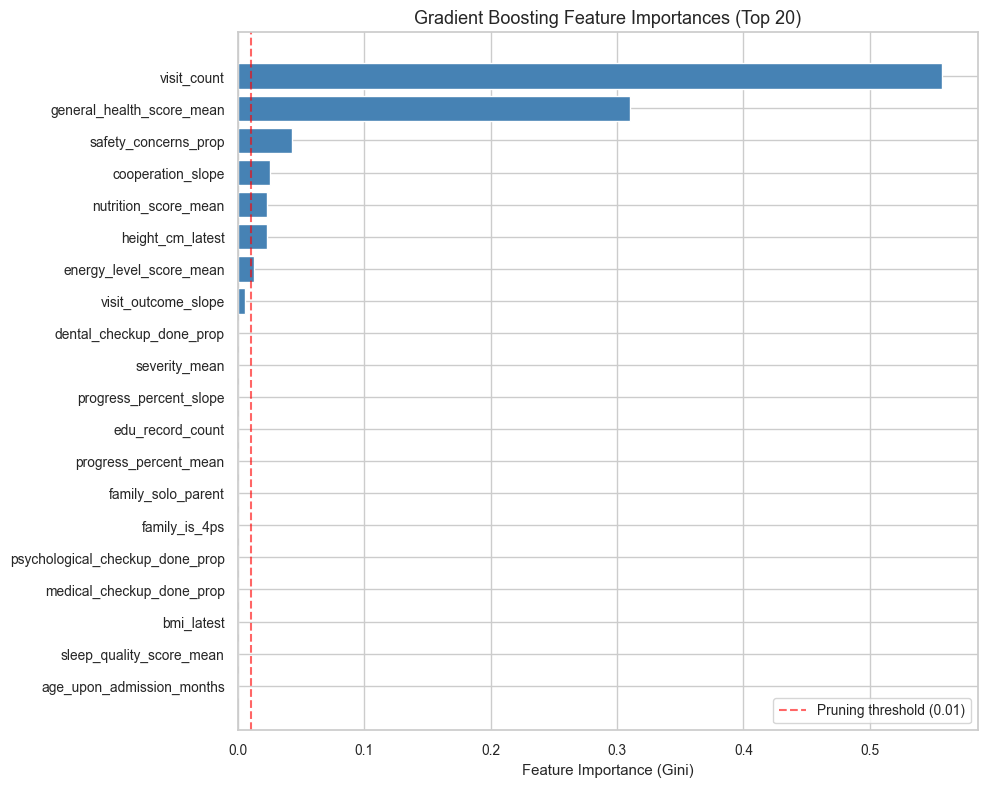

Features below 0.01 importance threshold: 24 of 31
Features to prune: ['visit_outcome_slope', 'dental_checkup_done_prop', 'severity_mean', 'progress_percent_slope', 'edu_record_count', 'progress_percent_mean', 'family_solo_parent', 'family_is_4ps', 'psychological_checkup_done_prop', 'medical_checkup_done_prop', 'bmi_latest', 'sleep_quality_score_mean', 'age_upon_admission_months', 'incident_count', 'incident_has_runaway', 'incident_resolution_rate', 'plan_safety_status', 'plan_physical_health_status', 'plan_education_status', 'severity_slope', 'visit_outcome_mean', 'emotional_state_end_mean', 'session_duration_mean', 'sw_distinct_count']

Full importance table:
                        feature  importance
                    visit_count    0.557420
      general_health_score_mean    0.310428
           safety_concerns_prop    0.042378
              cooperation_slope    0.025306
           nutrition_score_mean    0.023277
               height_cm_latest    0.022516
        energy_level_s

In [37]:
# -- 6a. Extract feature importances from best predictive model (Gini) ------
import matplotlib
import matplotlib.pyplot as plt

best_gb = models['Gradient Boosting'].best_estimator_
gb_importances = best_gb.named_steps['clf'].feature_importances_

fi_df = pd.DataFrame({
    'feature': vif_features,
    'importance': gb_importances,
}).sort_values('importance', ascending=False)

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(fi_df))
fi_plot = fi_df.head(top_n)
ax.barh(fi_plot['feature'][::-1], fi_plot['importance'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Gradient Boosting Feature Importances (Top {top_n})', fontsize=13)
ax.axvline(0.01, color='red', linestyle='--', alpha=0.6, label='Pruning threshold (0.01)')
ax.legend()
plt.tight_layout()
plt.show()

IMPORTANCE_THRESHOLD = 0.01
low_imp_features = fi_df[fi_df['importance'] < IMPORTANCE_THRESHOLD]['feature'].tolist()

print(f"Features below {IMPORTANCE_THRESHOLD} importance threshold: {len(low_imp_features)} of {len(fi_df)}")
print(f"Features to prune: {low_imp_features}")
print(f"\nFull importance table:")
print(fi_df.to_string(index=False))

In [38]:
# -- 6b. Retrain without low-importance features and compare --------------
final_features = [f for f in vif_features if f not in low_imp_features]
print(f"Final features ({len(final_features)}): {final_features}")
print(f"Dropped: {low_imp_features}")

X_train_pruned = X_train[final_features]
X_test_pruned = X_test[final_features]

gb_pruned_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('clf', GradientBoostingClassifier(random_state=42))]),
    param_grid={
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [2, 3],
        'clf__learning_rate': [0.05, 0.1],
    },
    cv=cv, scoring='roc_auc', refit=True,
)
gb_pruned_grid.fit(X_train_pruned, y_train)

full_auc = models['Gradient Boosting'].best_score_
pruned_auc = gb_pruned_grid.best_score_

print(f"\nCross-validated AUC-ROC comparison:")
print(f"  Full model    ({len(vif_features)} features):   {full_auc:.3f}")
print(f"  Pruned model  ({len(final_features)} features):   {pruned_auc:.3f}")
print(f"  Difference:                       {pruned_auc - full_auc:+.3f}")

if pruned_auc >= full_auc - 0.01:
    print("\nPruned model performs equivalently -- adopting the leaner model.")
    final_model = gb_pruned_grid.best_estimator_
    final_model_features = final_features
else:
    print("\nPruning degraded performance -- keeping full model.")
    final_model = models['Gradient Boosting'].best_estimator_
    final_model_features = vif_features

# Refit final model on ALL data
final_model.fit(final_df[final_model_features], y)
print(f"\nFinal model refit on all {len(final_df)} residents.")
print(f"Final model: GradientBoosting, features: {final_model_features}")

Final features (7): ['general_health_score_mean', 'nutrition_score_mean', 'energy_level_score_mean', 'height_cm_latest', 'visit_count', 'cooperation_slope', 'safety_concerns_prop']
Dropped: ['visit_outcome_slope', 'dental_checkup_done_prop', 'severity_mean', 'progress_percent_slope', 'edu_record_count', 'progress_percent_mean', 'family_solo_parent', 'family_is_4ps', 'psychological_checkup_done_prop', 'medical_checkup_done_prop', 'bmi_latest', 'sleep_quality_score_mean', 'age_upon_admission_months', 'incident_count', 'incident_has_runaway', 'incident_resolution_rate', 'plan_safety_status', 'plan_physical_health_status', 'plan_education_status', 'severity_slope', 'visit_outcome_mean', 'emotional_state_end_mean', 'session_duration_mean', 'sw_distinct_count']

Cross-validated AUC-ROC comparison:
  Full model    (31 features):   0.917
  Pruned model  (7 features):   0.940
  Difference:                       +0.024

Pruned model performs equivalently -- adopting the leaner model.

Final mode

In [39]:
# -- 7a. Serialize the final model for deployment -------------------------
import joblib
from pathlib import Path

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / 'resident_risk_model.joblib'
joblib.dump(final_model, model_path)

feature_config = {
    'numeric_features': final_model_features,
    'target': 'at_risk',
    'risk_thresholds': {'High': 0.6, 'Medium': 0.3, 'Low': 0.0},
    'class_labels': {0: 'Progressing', 1: 'At-risk'},
    'training_n': len(final_df),
}
config_path = MODEL_DIR / 'resident_risk_feature_config.joblib'
joblib.dump(feature_config, config_path)

print(f"Model saved:         {model_path} ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"Feature config saved: {config_path}")

# Verify the saved model loads and scores correctly
loaded_model = joblib.load(model_path)
sample_scores = loaded_model.predict_proba(final_df[final_model_features])[:, 1]
print(f"\nVerification: loaded model produces {len(sample_scores)} risk scores.")
print(f"Score range: {sample_scores.min():.3f} -- {sample_scores.max():.3f}")
print(f"Mean risk score: {sample_scores.mean():.3f}")
print(f"\nDeployment note: This model and feature_config are ready for integration into")
print(f"the web application API (see ml.md for deployment pipeline specifications).")

Model saved:         models\resident_risk_model.joblib (78.9 KB)
Feature config saved: models\resident_risk_feature_config.joblib

Verification: loaded model produces 60 risk scores.
Score range: 0.007 -- 0.978
Mean risk score: 0.334

Deployment note: This model and feature_config are ready for integration into
the web application API (see ml.md for deployment pipeline specifications).
